In [1]:
import copy

import torch
import torch.nn as nn
import torchvision
import numpy as np
from matplotlib import pyplot as plt

from its.search import InverseTransformationSearch
from search.parallel_gradient import ParallelGradientDescent
from utils.affine_transforms_old import AffineTransformation2D
from utils.sampling import BatchNegativeSampler

#torch.cuda.is_available = lambda: False
#device = torch.device("cpu")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#look for experiment files in parents
import os

path_found = False
current_path = os.getcwd()
while not path_found:
    if os.path.exists(os.path.join(current_path, "experiment_files")):
        path_found = True
        break
    current_path = os.path.dirname(current_path)

experiment_files_path_data = os.path.join(current_path, "experiment_files", "data")
dataset = "bigger_mnist"

default_architecutre_mapping = {
    "mnist":"resnet_small",
    "bigger_mnist":"resnet_small",
    "emnist": "extended_resnet_small",
    "bigger_emnist":"bigger_extended_resnet_small",
    "coil100":"coil_resnet_small",
    "tu_berlin":"bi_lstm",
    "modelnet10":"pointnetplus",
}



architecture = default_architecutre_mapping[dataset]
budget = None

In [2]:
from utils.transforms.apply import grid_resample_border,grid_resample_reflection

In [3]:
from experiment_thesis.dataset_preperation.get_dataset import get_dataset_info,get_dataset

dataset_info = get_dataset_info(dataset)

dataset_dict = get_dataset(dataset_info,path=experiment_files_path_data, batch_size=dataset_info.batch_size)
transform_name = dataset_info.transform_seq_name

In [4]:


dataset_dict.keys()
dataset_train = dataset_dict['train_dataset']
dataset_val = dataset_dict['val_dataset']
dataset_test = dataset_dict['test_dataset']
train_loader = dataset_dict['train_loader']
val_loader = dataset_dict['val_loader']
test_loader = dataset_dict['test_loader']
n_classes = dataset_info.num_classes
train_loader_transformed = dataset_dict['train_loader_transformed']
val_loader_transformed = dataset_dict['val_loader_transformed']
test_loader_transformed = dataset_dict['test_loader_transformed']
train_loader_no_shuffle = dataset_dict['train_loader_no_shuffle']

In [5]:
x=next(iter(test_loader_transformed))[0]

In [6]:
batch_size = next(iter(train_loader))[0].shape[0]


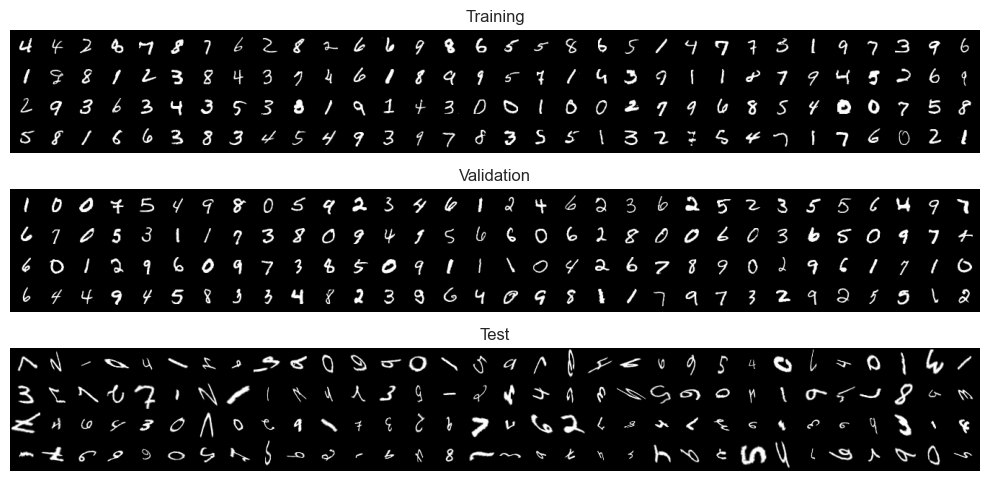

In [7]:
from utils.eval.vis import vis_dataset, plt_setup_latex

vis_dataset(train_loader,val_loader,test_loader_transformed)

In [8]:
from experiment_thesis.main import train_and_get_model,train_or_load_energy_model
from experiment_thesis.dataset_preperation.basic_networks import get_network
from utils.eval.main_model import evaluate_base_model

model_dir_path = os.path.join(current_path, "experiment_files", "models")
embedding_cache_path = os.path.join(current_path, "experiment_files", "embedding_cache")
# Add results dir and helper for save paths
results_dir_path = os.path.join(current_path, "experiment_files", "results", dataset, architecture, "comparison_supervised_methods")
os.makedirs(results_dir_path, exist_ok=True)


def savepath(label: str) -> str:
    safe = "".join(c if c.isalnum() or c in "-_." else "_" for c in label)
    return os.path.join(results_dir_path,transform_name, f"{safe}.json")

In [9]:
model = get_network(dataset_info,architecture, num_classes=n_classes).to(device)
modelname = f"{dataset}_{architecture}"
cache_name_train= f"{dataset}_{architecture}_embedding_cache_train"

train_and_get_model(model,model_dir_path,modelname, train_loader, val_loader , trainer_kwargs= {
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs,
        "precision": "16-mixed",
},load_if_exists=True)



Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small.safetensors


(FlexibleResNet(
   (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
   (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
   (stem_act): GELU(approximate='none')
   (stages): ModuleList(
     (0): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
         (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
         (act): GELU(approximate='none')
       )
     )
     (1): Sequential(
       (0): BasicBlock(
         (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
         (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    

In [10]:
model.eval().to(device)

FlexibleResNet(
  (stem_conv): Conv2d(1, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (stem_bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (stem_act): GELU(approximate='none')
  (stages): ModuleList(
    (0): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (act): GELU(approximate='none')
      )
    )
    (1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2

In [11]:
#chek if data is image data
is_image_data = len(dataset_info.input_size) == 3 and dataset_info.input_size[0] in [1, 3]

In [12]:
is_image_data = len(dataset_info.input_size) == 3 and dataset_info.input_size[0] in [1, 3]


from utils.replacer import replace_rotation_transforms_2vec


from utils.transforms.apply import grid_resample
from experiment_thesis.dataset_preperation.transformation import get_transformation_sequence_images

transform_seq = get_transformation_sequence_images(
    name=dataset_info.transform_seq_name,
    resample_method=dataset_info.resample_method,
    init_method="sobol"
).to(device)

if dataset == "modelnet10":
    transform_seq = replace_rotation_transforms_2vec(transform_seq)

In [13]:
from experiment_thesis.dataset_preperation.basic_networks import get_network_layer

layer,layer_io = get_network_layer(dataset_info, architecture, 0, num_classes=None, num_rotations=8)

In [14]:
from confidence.direct.logit_based import EnergyConfidence
from utils.transformation_problem import TransformationProblem
from confidence.model.single_pass import SinglePassConfidence

logit_energy = SinglePassConfidence(model, EnergyConfidence(), index=None)
problem_energy_logits = TransformationProblem(logit_energy, transform_seq,                                              consolidate_method="consolidate_simple")
#test ot
from search.shgo import SHGO
optimizer = SHGO(initial_samples=46, local_runs=2, local_max_steps=3,local_opt_kwargs={"lr":0.1})
if dataset == "tu_berlin":
    optimizer = SHGO(initial_samples=60,local_runs=1,local_max_steps=0,local_opt_kwargs={"lr":0.1})


from utils.eval.ood_performance import load_or_run_evaluate_confidence_and_search, evaluate_confidence_and_search, \
    ITSWRAPPER


In [15]:
res=load_or_run_evaluate_confidence_and_search(
    model, optimizer=optimizer, problem=problem_energy_logits,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("energy_confidence_transformed"), show_progress=True,
    repeats=1)

In [16]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [17]:
from utils.augments import ComposeAugmentations, random_gaussian_noise, random_contrast, \
    random_gamma  ,random_blur_or_sharpen,build_default_augmentations
import utils.augments

@torch.no_grad()
def dec_strat(x, idd, y_true):
    out = model(x)
    eq = out.argmax(dim=-1) == y_true
    #convert to tensor where y>=0 if correct, y<0 if incorrect
    y = torch.where(eq, y_true, -1)
    return y


from utils.augments import build_default_augmentations, small_affine_augment_2d
from utils.sampling_strategy import GaussianSamplingStrategyLatent, TransformLatentSamplingStrategy
import importlib
import utils.sampling_strategy
import utils.sampling

importlib.reload(utils.sampling)
from utils.sampling import BatchNegativeSampler


energy_model2 = get_network(dataset_info,architecture, num_classes=1).to(device)

from experiment_thesis.main import train_or_load_energy_model

if is_image_data:
    transform_true_function = small_affine_augment_2d
    multiple_augment = utils.augments.build_default_augmentations()
    affine_augment = ComposeAugmentations([
        lambda x: random_blur_or_sharpen(x, p=0.8, prob_blur=0.5,
                                         blur_ks_choices=(3, 5), blur_sigma_range=(0.2, 1.8),
                                         usm_ksize=5, usm_sigma_range=(0.5, 1.5),
                                         usm_amount_range=(0.5, 1.3), clamp=True),

    ])
else:
    transform_true_function = None
    affine_augment = None
    multiple_augment = None

negative_sampling_module = BatchNegativeSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, ), transform_true_function
    =transform_true_function, augment_function=multiple_augment,
    decision_strategy=dec_strat,
)

energy_conf_default = train_or_load_energy_model(
    energy_model2, model_dir_path, f"{modelname}_energy2", train_loader,
    val_loader, trainer_kwargs={
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs//2,
        "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
    }, negative_sampling_module=negative_sampling_module, load_if_exists=True)

energy_conf_default.to(device).eval()



problem_energy_default = TransformationProblem(energy_conf_default, transform_seq,                                              consolidate_method="consolidate_simple")

res=load_or_run_evaluate_confidence_and_search(
    model, optimizer=optimizer, problem=problem_energy_default,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("learned_energy_confidence_transformed"), show_progress=True,
    repeats=1)

#unload values
del energy_model2
del energy_conf_default
del problem_energy_default
print(res)


Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_energy2_energy_conf_best.safetensors
Model has non-negative constraint: False

{'repeats': 5, 'accuracy_mean': 0.9739400148391724, 'accuracy_std': 0.0008706158841960132, 'accuracy_se': 0.00038935125987067404, 'f2_macro_mean': 0.9737274050712585, 'f2_macro_std': 0.0008996843243949115, 'f2_macro_se': 0.0004023510615275989, 'f2_micro_mean': 0.9739400148391724, 'f2_micro_std': 0.0008706158841960132, 'f2_micro_se': 0.00038935125987067404, 'f2_weighted_mean': 0.9739057421684265, 'f2_weighted_std': 0.0008725443622097373, 'f2_weighted_se': 0.0003902137014570342, 'per_run': [{'accuracy': 0.974399983882904, 'f2_macro': 0.9742429256439209, 'f2_micro': 0.974399983882904, 'f2_weighted': 0.9743747711181641, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': None}, {'accuracy': 0

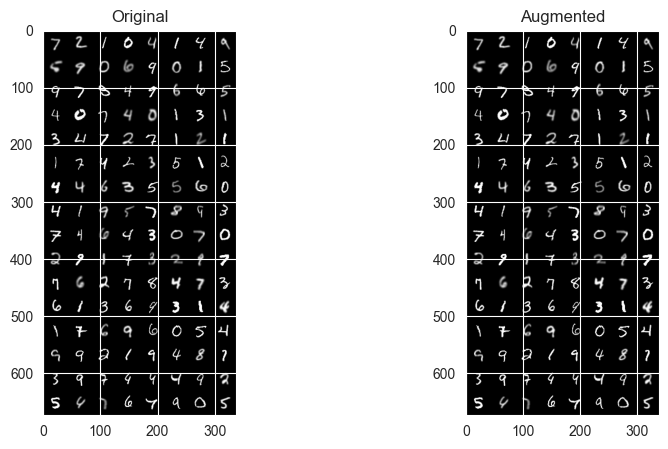

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.66834116..0.6742207].


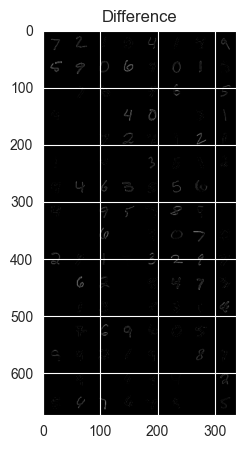

In [18]:
if is_image_data:
    x = next(iter(test_loader))[0]
    x_augmented = affine_augment(x)
    plt.figure(figsize=(10,5))
    ax = plt.subplot(1,2,1)
    ax.set_title("Original")
    if False:
        plt.imshow(torchvision.utils.make_grid(x_augmented, nrow=8).cpu().squeeze(), cmap='gray')
    else:
        plt.imshow(torchvision.utils.make_grid(x_augmented, nrow=8).cpu().permute(1,2,0))
    ax = plt.subplot(1,2,2)
    ax.set_title("Augmented")
    if False:
        plt.imshow(torchvision.utils.make_grid(x_augmented, nrow=8).cpu().squeeze(), cmap='gray')
    else:
        plt.imshow(torchvision.utils.make_grid(x_augmented, nrow=8).cpu().permute(1,2,0))
    plt.show()
    dif = x - x_augmented
    plt.figure(figsize=(5,5))
    plt.title("Difference")
    if False:
        plt.imshow(torchvision.utils.make_grid(dif, nrow=8).cpu().squeeze(), cmap='gray')
    else:
        plt.imshow(torchvision.utils.make_grid(dif, nrow=8).cpu().permute(1,2,0))


In [19]:
#if image data also test a variant without augmentations
if is_image_data:
    energy_model_no_aug = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_no_aug = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =None, augment_function=None,
        decision_strategy=dec_strat,
    )

    energy_conf_no_aug = train_or_load_energy_model(
        copy.deepcopy(energy_model_no_aug), model_dir_path, f"{modelname}_energy2_no_aug", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
        }, negative_sampling_module=negative_sampling_module_no_aug, load_if_exists=True)
    energy_conf_no_aug.to(device).eval()
    problem_energy_no_aug = TransformationProblem(energy_conf_no_aug, transform_seq,                                              consolidate_method="consolidate_simple")

    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_no_aug,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_no_aug_transformed"), show_progress=True,
        repeats=1)

    #unload values
    del energy_model_no_aug
    del energy_conf_no_aug
    del problem_energy_no_aug
    print(res)

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_energy2_no_aug_energy_conf_best.safetensors
Model has non-negative constraint: False

{'repeats': 5, 'accuracy_mean': 0.9629600644111633, 'accuracy_std': 0.0012033178936690092, 'accuracy_se': 0.0005381401217571536, 'f2_macro_mean': 0.9628440737724304, 'f2_macro_std': 0.0012319032102823257, 'f2_macro_se': 0.0005509238639782996, 'f2_micro_mean': 0.9629600644111633, 'f2_micro_std': 0.0012033178936690092, 'f2_micro_se': 0.0005381401217571536, 'f2_weighted_mean': 0.9629027247428894, 'f2_weighted_std': 0.0012071890523657203, 'f2_weighted_se': 0.0005398713565566608, 'per_run': [{'accuracy': 0.9613000154495239, 'f2_macro': 0.9611346125602722, 'f2_micro': 0.9613000154495239, 'f2_weighted': 0.9612292051315308, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': None}, {'accur

In [20]:
#if image data also test a variant with only blur augmentations
if is_image_data:
    energy_model_no_aug = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_no_aug = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =transform_true_function, augment_function=affine_augment,
        decision_strategy=dec_strat,
    )

    energy_conf_no_aug = train_or_load_energy_model(
        copy.deepcopy(energy_model_no_aug), model_dir_path, f"{modelname}_energy2_only_blur_aug", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
        }, negative_sampling_module=negative_sampling_module_no_aug, load_if_exists=True)
    energy_conf_no_aug.to(device).eval()
    problem_energy_no_aug = TransformationProblem(energy_conf_no_aug, transform_seq,                                              consolidate_method="consolidate_simple")

    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_no_aug,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_only_blur_aug_transformed"), show_progress=True,
        repeats=1)

    #unload values
    del energy_model_no_aug
    del energy_conf_no_aug
    del problem_energy_no_aug
    print(res)

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_energy2_only_blur_aug_energy_conf_best.safetensors
Model has non-negative constraint: False

{'repeats': 5, 'accuracy_mean': 0.9725199937820435, 'accuracy_std': 0.0003271099703852087, 'accuracy_se': 0.00014628802597985396, 'f2_macro_mean': 0.9723920822143555, 'f2_macro_std': 0.00031104247318580747, 'f2_macro_se': 0.0001391024227866242, 'f2_micro_mean': 0.9725199937820435, 'f2_micro_std': 0.0003271099703852087, 'f2_micro_se': 0.00014628802597985396, 'f2_weighted_mean': 0.9724640846252441, 'f2_weighted_std': 0.00033241926576010883, 'f2_weighted_se': 0.0001486624150540343, 'per_run': [{'accuracy': 0.9731000065803528, 'f2_macro': 0.9729388952255249, 'f2_micro': 0.9731000065803528, 'f2_weighted': 0.9730530381202698, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': Non

In [21]:
#if image data also test a variant without augmentations
if is_image_data:
    energy_model_true_aug_only = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_true_aug_only = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =transform_true_function, augment_function=None,
        decision_strategy=dec_strat,
    )
    energy_conf_true_aug_only = train_or_load_energy_model(
        copy.deepcopy(energy_model_true_aug_only), model_dir_path, f"{modelname}_energy2_true_aug_only", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
        }, negative_sampling_module=negative_sampling_module_true_aug_only, load_if_exists=True)
    energy_conf_true_aug_only.to(device).eval()
    problem_energy_true_aug_only = TransformationProblem(energy_conf_true_aug_only, transform_seq,                                              consolidate_method="consolidate_simple")
    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_true_aug_only,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_true_aug_only_transformed"), show_progress=True,
        repeats=1)
    #unload values
    del energy_model_true_aug_only
    del energy_conf_true_aug_only
    del problem_energy_true_aug_only
    print(res)

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_energy2_true_aug_only_energy_conf_best.safetensors
Model has non-negative constraint: False

{'repeats': 5, 'accuracy_mean': 0.9704999923706055, 'accuracy_std': 0.0010222515556961298, 'accuracy_se': 0.00045716479372829167, 'f2_macro_mean': 0.970356285572052, 'f2_macro_std': 0.001037344802170992, 'f2_macro_se': 0.00046391469875208186, 'f2_micro_mean': 0.9704999923706055, 'f2_micro_std': 0.0010222515556961298, 'f2_micro_se': 0.00045716479372829167, 'f2_weighted_mean': 0.9704540371894836, 'f2_weighted_std': 0.0010296639520674944, 'f2_weighted_se': 0.0004604797181608005, 'per_run': [{'accuracy': 0.9710999727249146, 'f2_macro': 0.9709105491638184, 'f2_micro': 0.9710999727249146, 'f2_weighted': 0.9710621237754822, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': None},

In [22]:
if is_image_data:
    energy_model_no_true_aug = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_no_true_aug = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =None, augment_function=affine_augment,
        decision_strategy=dec_strat,
    )
    energy_conf_no_true_aug = train_or_load_energy_model(
        copy.deepcopy(energy_model_no_true_aug), model_dir_path, f"{modelname}_energy2_no_true_aug", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
        }, negative_sampling_module=negative_sampling_module_no_true_aug, load_if_exists=True)
    energy_conf_no_true_aug.to(device).eval()
    problem_energy_no_true_aug = TransformationProblem(energy_conf_no_true_aug, transform_seq,                                              consolidate_method="consolidate_simple")
    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_no_true_aug,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_no_true_aug_transformed"), show_progress=True,
        repeats=1)
    #unload values
    del energy_model_no_true_aug
    del energy_conf_no_true_aug
    del problem_energy_no_true_aug
    print(res)

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_energy2_no_true_aug_energy_conf_best.safetensors
Model has non-negative constraint: False

{'repeats': 5, 'accuracy_mean': 0.9768999814987183, 'accuracy_std': 0.0009772491175681353, 'accuracy_se': 0.0004370390915668069, 'f2_macro_mean': 0.9767206311225891, 'f2_macro_std': 0.0009587136446498334, 'f2_macro_se': 0.000428749776078721, 'f2_micro_mean': 0.9768999814987183, 'f2_micro_std': 0.0009772491175681353, 'f2_micro_se': 0.0004370390915668069, 'f2_weighted_mean': 0.9768736958503723, 'f2_weighted_std': 0.0009781543631106615, 'f2_weighted_se': 0.0004374439296806903, 'per_run': [{'accuracy': 0.9764999747276306, 'f2_macro': 0.9763160943984985, 'f2_micro': 0.9764999747276306, 'f2_weighted': 0.9764745831489563, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': None}, {'a

C:\Users\Lindner\AppData\Local\Temp\ipykernel_25472\230457366.py:38: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=df_mean, ci=None)


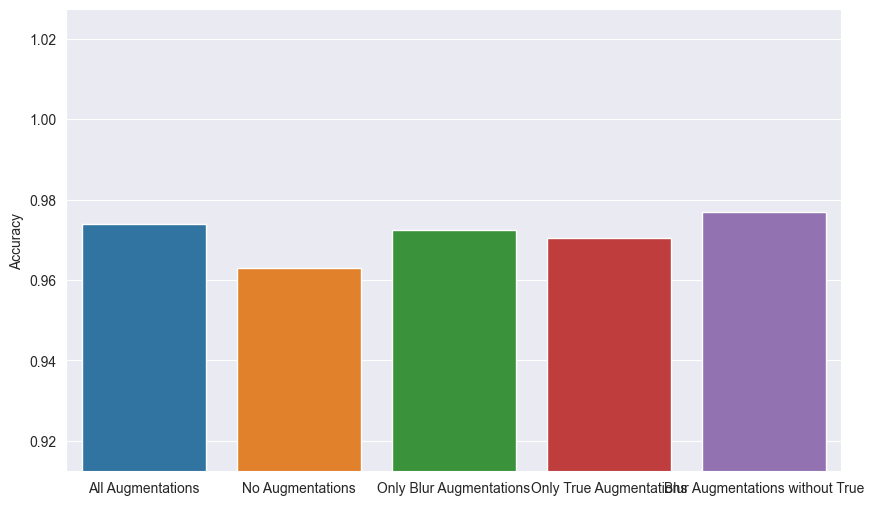

In [23]:
import pandas as pd
import json


#load the different results
res_all_augment = json.load(open(savepath("learned_energy_confidence_transformed"), "r"))
res_no_augment = json.load(open(savepath("learned_energy_confidence_no_aug_transformed"), "r"))
#only blur augment plus true
res_blur_augment = json.load(open(savepath("learned_energy_confidence_only_blur_aug_transformed"), "r"))
#only true augment
res_true_augment_only = json.load(open(savepath("learned_energy_confidence_true_aug_only_transformed"), "r"))
#only blur without true
res_blur_no_true = json.load(open(savepath("learned_energy_confidence_no_true_aug_transformed"), "r"))

#plot accuracy mean of them with accuracy se as error bars

df_mean = pd.DataFrame({
    "All Augmentations": [res_all_augment['accuracy_mean']],
    "No Augmentations": [res_no_augment['accuracy_mean']],
    "Only Blur Augmentations": [res_blur_augment['accuracy_mean']],
    "Only True Augmentations": [res_true_augment_only['accuracy_mean']],
    "Blur Augmentations without True": [res_blur_no_true['accuracy_mean']],
})
df_se = pd.DataFrame({
    "All Augmentations": [res_all_augment['accuracy_se']],
    "No Augmentations": [res_no_augment['accuracy_se']],
    "Only Blur Augmentations": [res_blur_augment['accuracy_se']],
    "Only True Augmentations": [res_true_augment_only['accuracy_se']],
    "Blur Augmentations without True": [res_blur_no_true['accuracy_se']],
})
#set df set none to 0
df_se = df_se.fillna(0)
df = pd.merge(df_mean, df_se, left_index=True, right_index=True, suffixes=('_mean', '_se'))

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,6))
ax = sns.barplot(data=df_mean, ci=None)
ax.set_ylabel("Accuracy")
#ylim based on min and max of means +/- se plus some margin


ymin = (df_mean - df_se).min().min() - 0.05
ymax = (df_mean + df_se).max().max() + 0.05
ax.set_ylim(ymin, ymax)
plt.show()


In [24]:
#now test the variant that uses no dec strat
energy_model_no_dec_strat = get_network(dataset_info,architecture, num_classes=1).to(device)
negative_sampling_module_no_dec_strat = BatchNegativeSampler(
    TransformLatentSamplingStrategy(
        transform_sequence=transform_seq, ), transform_true_function
    =transform_true_function, augment_function=affine_augment,
    decision_strategy=None,
)
energy_conf_no_dec_strat = train_or_load_energy_model(
    copy.deepcopy(energy_model_no_dec_strat), model_dir_path, f"{modelname}_energy2_no_dec_strat", train_loader,
    val_loader, trainer_kwargs={
        "accelerator": "auto",
        "max_epochs": dataset_info.epochs//2,
        "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
    }, negative_sampling_module=negative_sampling_module_no_dec_strat, load_if_exists=True)
energy_conf_no_dec_strat.to(device).eval()
problem_energy_no_dec_strat = TransformationProblem(energy_conf_no_dec_strat, transform_seq,                                              consolidate_method="consolidate_simple")
res=load_or_run_evaluate_confidence_and_search(
    model, optimizer=optimizer, problem=problem_energy_no_dec_strat,
    test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
    save_path=savepath("learned_energy_confidence_no_dec_strat_transformed"), show_progress=True,
    repeats=1)
del energy_model_no_dec_strat
del energy_conf_no_dec_strat
del problem_energy_no_dec_strat
print(res)

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_energy2_no_dec_strat_energy_conf_best.safetensors
Model has non-negative constraint: False

{'repeats': 5, 'accuracy_mean': 0.7727400064468384, 'accuracy_std': 0.0013520398642867804, 'accuracy_se': 0.0006046506089669662, 'f2_macro_mean': 0.7692512273788452, 'f2_macro_std': 0.0014495030045509338, 'f2_macro_se': 0.000648237450353215, 'f2_micro_mean': 0.7727400064468384, 'f2_micro_std': 0.0013520398642867804, 'f2_micro_se': 0.0006046506089669662, 'f2_weighted_mean': 0.7717326879501343, 'f2_weighted_std': 0.001360073802061379, 'f2_weighted_se': 0.0006082434951651674, 'per_run': [{'accuracy': 0.7714999914169312, 'f2_macro': 0.7679309844970703, 'f2_micro': 0.7714999914169312, 'f2_weighted': 0.7705754041671753, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': None}, {'a

In [25]:
#now no dec strat no augmentations
if is_image_data:
    energy_model_no_dec_strat_no_aug = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_no_dec_strat_no_aug = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =None, augment_function=None,
        decision_strategy=None,
    )
    energy_conf_no_dec_strat_no_aug = train_or_load_energy_model(
        copy.deepcopy(energy_model_no_dec_strat_no_aug), model_dir_path, f"{modelname}_energy2_no_dec_strat_no_aug", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
        }, negative_sampling_module=negative_sampling_module_no_dec_strat_no_aug, load_if_exists=True)
    energy_conf_no_dec_strat_no_aug.to(device).eval()
    problem_energy_no_dec_strat_no_aug = TransformationProblem(energy_conf_no_dec_strat_no_aug, transform_seq,                                              consolidate_method="consolidate_simple")
    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_no_dec_strat_no_aug,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_no_dec_strat_no_aug_transformed"), show_progress=True,
        repeats=1)
    del energy_model_no_dec_strat_no_aug
    del energy_conf_no_dec_strat_no_aug
    del problem_energy_no_dec_strat_no_aug
    print(res)


Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_energy2_no_dec_strat_no_aug_energy_conf_best.safetensors
Model has non-negative constraint: False

{'repeats': 5, 'accuracy_mean': 0.43804001808166504, 'accuracy_std': 0.0017314740689471364, 'accuracy_se': 0.0007743387438887909, 'f2_macro_mean': 0.42740002274513245, 'f2_macro_std': 0.0017361690988764167, 'f2_macro_se': 0.0007764384251044442, 'f2_micro_mean': 0.43804001808166504, 'f2_micro_std': 0.0017314740689471364, 'f2_micro_se': 0.0007743387438887909, 'f2_weighted_mean': 0.43055906891822815, 'f2_weighted_std': 0.001743334112688899, 'f2_weighted_se': 0.0007796427166933313, 'per_run': [{'accuracy': 0.44020000100135803, 'f2_macro': 0.4296504259109497, 'f2_micro': 0.44020000100135803, 'f2_weighted': 0.432837575674057, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct

C:\Users\Lindner\AppData\Local\Temp\ipykernel_25472\2717862779.py:28: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=df_mean, ci=None)


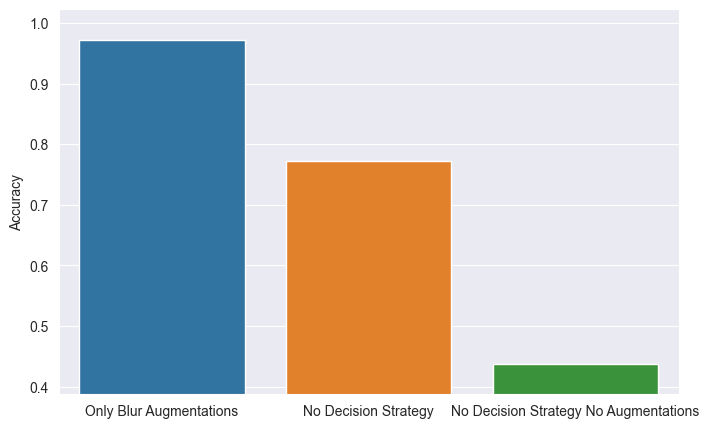

In [26]:
#plot three results

res_blur_augment = json.load(open(savepath("learned_energy_confidence_only_blur_aug_transformed"), "r"))

res_no_dec_strat = json.load(open(savepath("learned_energy_confidence_no_dec_strat_transformed"), "r"))

res_no_dec_strat_no_aug = json.load(open(savepath("learned_energy_confidence_no_dec_strat_no_aug_transformed"), "r"))

df_mean = pd.DataFrame({
    "Only Blur Augmentations": [res_blur_augment['accuracy_mean']],
    "No Decision Strategy": [res_no_dec_strat['accuracy_mean']],
    "No Decision Strategy No Augmentations": [res_no_dec_strat_no_aug['accuracy_mean']],
})
df_se = pd.DataFrame({
    "Only Blur Augmentations": [res_blur_augment['accuracy_se']],
    "No Decision Strategy": [res_no_dec_strat['accuracy_se']],
    "No Decision Strategy No Augmentations": [res_no_dec_strat_no_aug['accuracy_se']],
})

#set df set none to 0
df_se = df_se.fillna(0)

df = pd.merge(df_mean, df_se, left_index=True, right_index=True, suffixes=('_mean', '_se'))

import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(8,5))
ax = sns.barplot(data=df_mean, ci=None)
ax.set_ylabel("Accuracy")
#ylim based on min and max of means +/- se plus some margin

ymin = (df_mean - df_se).min().min() - 0.05
ymax = (df_mean + df_se).max().max() + 0.05
ax.set_ylim(ymin, ymax)
plt.show()







In [27]:
from confidence.supervised.ml.equiadapt import EquiCanonicalizationConfidence

In [28]:
if is_image_data and dataset == "bigger_mnist":
    from experiment_thesis.main import train_or_load_equi_canon_model
    negative_sampling_module = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq,),transform_true_function
        = transform_true_function,augment_function=affine_augment,
        decision_strategy =None, number_of_negatives=3,
    )
    canon = get_network(dataset_info,architecture, num_classes=128).to(device)

    from model.classifier import MyProgressBar
    from pytorch_lightning.callbacks import ModelCheckpoint

    conf_equi = train_or_load_equi_canon_model(
        canonicalization_network=canon,
        main_model=model,
        model_dir_path=model_dir_path,
        model_name=f"{modelname}_equi_canon",
        train_loader=train_loader,
        val_loader=val_loader,
        vector_dim=128,
        negative_sampling_module=negative_sampling_module,
        prior_loss_multiplier=0.1,
        diversity_loss_multiplier=0.01,
        reg_loss_multiplier=0.001,
        trainer_kwargs={"max_epochs": dataset_info.epochs//2},
        similarity_metric="cosine",
        learn_main_model=False,
        diversity_loss_type="variance",
    )
    conf_equi.to(device).eval()
    problem_equi_canon = TransformationProblem(
        conf_equi, transform_seq.to(device), consolidate_method="consolidate_simple"
    )
    res=load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_equi_canon,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("equi_canon_confidence_transformed"), show_progress=True,
        repeats=1)
    del canon
    del conf_equi
    del problem_equi_canon
    print(res)

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_equi_canon_equi_canon_best.safetensors

{'repeats': 1, 'accuracy_mean': 0.7979000210762024, 'accuracy_std': 0.0, 'accuracy_se': None, 'f2_macro_mean': 0.7922848463058472, 'f2_macro_std': 0.0, 'f2_macro_se': None, 'f2_micro_mean': 0.7979000210762024, 'f2_micro_std': 0.0, 'f2_micro_se': None, 'f2_weighted_mean': 0.7944005727767944, 'f2_weighted_std': 0.0, 'f2_weighted_se': None, 'per_run': [{'accuracy': 0.7979000210762024, 'f2_macro': 0.7922848463058472, 'f2_micro': 0.7979000210762024, 'f2_weighted': 0.7944005727767944, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': None}]}


In [29]:
#no augment case for images data
if is_image_data and dataset == "bigger_mnist":
    negative_sampling_module_no_aug = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq,),transform_true_function
        = None,augment_function=None,
        decision_strategy =None, number_of_negatives=3,
    )
    canon_no_aug = get_network(dataset_info,architecture, num_classes=128).to(device)
    conf_equi_no_aug = train_or_load_equi_canon_model(
        canonicalization_network=canon_no_aug,
        main_model=model,
        model_dir_path=model_dir_path,
        model_name=f"{modelname}_equi_canon_no_aug",
        train_loader=train_loader,
        val_loader=val_loader,
        vector_dim=128,
        negative_sampling_module=negative_sampling_module_no_aug,
        prior_loss_multiplier=0.1,
        diversity_loss_multiplier=0.01,
        reg_loss_multiplier=0.001,
        trainer_kwargs={"max_epochs": dataset_info.epochs//2},
        similarity_metric="cosine",
        learn_main_model=False,
        diversity_loss_type="variance",
    )
    conf_equi_no_aug.to(device).eval()
    problem_equi_canon_no_aug = TransformationProblem(
        conf_equi_no_aug, transform_seq, consolidate_method="consolidate_simple"
    )
    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_equi_canon_no_aug,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("equi_canon_confidence_no_aug_transformed"), show_progress=True,
        repeats=1)
    del canon_no_aug
    del conf_equi_no_aug
    del problem_equi_canon_no_aug
    print(res)

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_equi_canon_no_aug_equi_canon_best.safetensors

{'repeats': 1, 'accuracy_mean': 0.5181000232696533, 'accuracy_std': 0.0, 'accuracy_se': None, 'f2_macro_mean': 0.5046896934509277, 'f2_macro_std': 0.0, 'f2_macro_se': None, 'f2_micro_mean': 0.5181000232696533, 'f2_micro_std': 0.0, 'f2_micro_se': None, 'f2_weighted_mean': 0.5083999633789062, 'f2_weighted_std': 0.0, 'f2_weighted_se': None, 'per_run': [{'accuracy': 0.5181000232696533, 'f2_macro': 0.5046896934509277, 'f2_micro': 0.5181000232696533, 'f2_weighted': 0.5083999633789062, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': None}]}


In [30]:
if is_image_data and dataset == "bigger_mnist":
    #now with training of the main model
    main_model2 = get_network(dataset_info,architecture, num_classes=n_classes).to(device)
    #same name to reload weights
    train_and_get_model(main_model2,model_dir_path,modelname, train_loader, val_loader , trainer_kwargs= {
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs,
            "precision": "16-mixed",
    },load_if_exists=True)

    negative_sampling_module_2 = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq,),transform_true_function
        = transform_true_function,augment_function=affine_augment,
        decision_strategy =None, number_of_negatives=3,
    )

    canon_high_reg = get_network(dataset_info,architecture, num_classes=128).to(device)
    conf_equi_high_reg = train_or_load_equi_canon_model(
        canonicalization_network=canon_high_reg,
        main_model=main_model2,
        model_dir_path=model_dir_path,
        model_name="f{modelname}_equi_canon_trained_main_model_high_reg",
        train_loader=train_loader,
        val_loader=val_loader,
        vector_dim=128,
        negative_sampling_module=negative_sampling_module,
        prior_loss_multiplier=10.0,
        diversity_loss_multiplier=0.1,
        reg_loss_multiplier=0.01,
        trainer_kwargs={"max_epochs": dataset_info.epochs//2},
        similarity_metric="cosine",
        learn_main_model=True,
        diversity_loss_type="variance",
    )
    #check if main model2 is stored at path
    if os.path.exists(os.path.join(model_dir_path, f"{modelname}_copy.ckpt")):
        #load weights into main_model2
        checkpoint = torch.load(os.path.join(model_dir_path, f"{modelname}_copy.ckpt"), map_location=device)
        main_model2.load_state_dict(checkpoint['state_dict'], strict=False)
    else:
        #save main model2
        torch.save({'state_dict': main_model2.state_dict()}, os.path.join(model_dir_path, f"{modelname}_copy.ckpt"))


    conf_equi_high_reg.to(device).eval()
    problem_equi_canon_high_reg = TransformationProblem(
        conf_equi_high_reg, transform_seq, consolidate_method="consolidate_simple"
    )

    res=load_or_run_evaluate_confidence_and_search(
        main_model2, optimizer=optimizer, problem=problem_equi_canon_high_reg,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("equi_canon_confidence_high_reg_transformed"), show_progress=True,
        repeats=1)

    res_base = evaluate_base_model(
        main_model2, test_loader_transformed
    )


    del canon_high_reg
    del conf_equi_high_reg
    del problem_equi_canon_high_reg
    del main_model2
    print(res)
    print(res_base)

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small.safetensors
Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\f{modelname}_equi_canon_trained_main_model_high_reg_equi_canon_best.safetensors



{'repeats': 1, 'accuracy_mean': 0.954200029373169, 'accuracy_std': 0.0, 'accuracy_se': None, 'f2_macro_mean': 0.953486979007721, 'f2_macro_std': 0.0, 'f2_macro_se': None, 'f2_micro_mean': 0.954200029373169, 'f2_micro_std': 0.0, 'f2_micro_se': None, 'f2_weighted_mean': 0.9541133642196655, 'f2_weighted_std': 0.0, 'f2_weighted_se': None, 'per_run': [{'accuracy': 0.954200029373169, 'f2_macro': 0.953486979007721, 'f2_micro': 0.954200029373169, 'f2_weighted': 0.9541133642196655, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': None}]}
{'accuracy': 0.9732999801635742, 'f2_macro': 0.9730821847915649, 'f2_micro': 0.9732999801635742, 'f2_weighted': 0.9732995629310608}


C:\Users\Lindner\AppData\Local\Temp\ipykernel_25472\3353383256.py:26: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  }).fillna(0)
C:\Users\Lindner\AppData\Local\Temp\ipykernel_25472\3353383256.py:30: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=df_mean, ci=None)


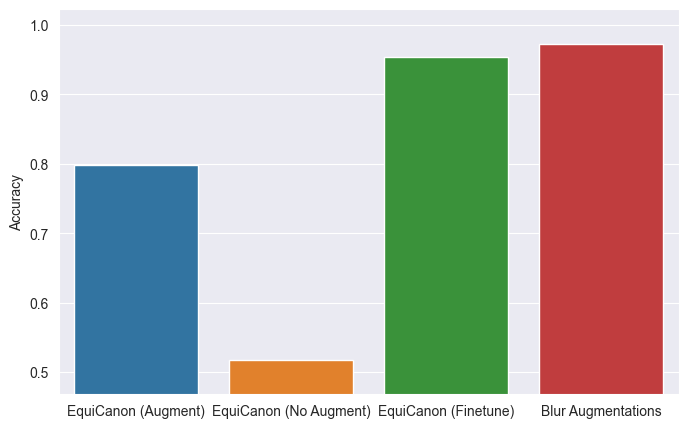

In [31]:
if dataset == "bigger_mnist" and is_image_data:
    import json
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Load results
    res_equi_canon = json.load(open(savepath("equi_canon_confidence_transformed"), "r"))
    res_equi_canon_no_aug = json.load(open(savepath("equi_canon_confidence_no_aug_transformed"), "r"))
    res_equi_canon_high_reg = json.load(open(savepath("equi_canon_confidence_high_reg_transformed"), "r"))
    res_blur_augment = json.load(open(savepath("learned_energy_confidence_only_blur_aug_transformed"), "r"))


    # Prepare DataFrames
    df_mean = pd.DataFrame({
        "EquiCanon (Augment)": [res_equi_canon['accuracy_mean']],
        "EquiCanon (No Augment)": [res_equi_canon_no_aug['accuracy_mean']],
        "EquiCanon (Finetune)": [res_equi_canon_high_reg['accuracy_mean']],
        "Blur Augmentations": [res_blur_augment['accuracy_mean']],
    })
    df_se = pd.DataFrame({
        "EquiCanon (Augment)": [res_equi_canon['accuracy_se']],
        "EquiCanon (No Augment)": [res_equi_canon_no_aug['accuracy_se']],
        "EquiCanon (Finetune)": [res_equi_canon_high_reg['accuracy_se']],
        "Blur Augmentations": [res_blur_augment['accuracy_se']],
    }).fillna(0)

    # Plot
    plt.figure(figsize=(8,5))
    ax = sns.barplot(data=df_mean, ci=None)
    ax.set_ylabel("Accuracy")
    ymin = (df_mean - df_se).min().min() - 0.05
    ymax = (df_mean + df_se).max().max() + 0.05
    ax.set_ylim(ymin, ymax)
    plt.show()


In [32]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [33]:
from confidence.supervised.ml.vae_with_convex import ICNN, tst_convexity

if dataset=="bigger_mnist":
    from utils.augments import ComposeAugmentations, random_gaussian_noise, random_contrast, \
        random_gamma  ,random_blur_or_sharpen,build_default_augmentations
    import utils.augments

    def dec_strat(x, idd, y_true):
        out = model(x)
        eq = out.argmax(dim=-1) == y_true
        #convert to tensor where y>=0 if correct, y<0 if incorrect
        y = torch.where(eq, y_true, -1)
        return y


    from utils.augments import build_default_augmentations, small_affine_augment_2d
    from utils.sampling_strategy import GaussianSamplingStrategyLatent, TransformLatentSamplingStrategy
    import importlib
    import utils.sampling_strategy
    import utils.sampling

    importlib.reload(utils.sampling)
    from utils.sampling import BatchNegativeSampler


    energy_model3 = ICNN(n_filters=32, kernel_size=3, n_layers=8)

    class InvertLayer(torch.nn.Module):
        def __init__(self, layer):
            super().__init__()
            self.layer = layer

        def forward(self, x):
            return -self.layer(x)

    energy_model3 = InvertLayer(energy_model3).to(device)

    tst_convexity(energy_model3, torch.randn(1,1,40,40))



    from experiment_thesis.main import train_or_load_energy_model

    if is_image_data:
        transform_true_function = small_affine_augment_2d
        affine_augment = affine_augment
    else:
        transform_true_function = None
        affine_augment = None

    negative_sampling_module = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =transform_true_function, augment_function=affine_augment,
        decision_strategy=dec_strat,
    )

    energy_conf3 = train_or_load_energy_model(
        energy_model3, model_dir_path, f"{modelname}_energy_ICNN_inverted", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "32",
        }, negative_sampling_module=negative_sampling_module, load_if_exists=True, loss_type = "discriminator",monitor= "val_acc",monitor_mode="max",optimizer_type=torch.optim.AdamW,gp_weight=5.0)


    energy_conf3.to(device).eval()
    problem_energy_icnn = TransformationProblem(energy_conf3, transform_seq,                                              consolidate_method="consolidate_simple")
    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_icnn,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_icnn_transformed_inverted"), show_progress=True,
        repeats=5)

    del energy_model3
    del energy_conf3
    del problem_energy_icnn
    print(res)



running a numerical convexity test...
Failed convexity test!
Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_energy_ICNN_inverted_energy_conf_best.safetensors
Model has non-negative constraint: False

{'repeats': 5, 'accuracy_mean': 0.7680599689483643, 'accuracy_std': 0.0036807649303227663, 'accuracy_se': 0.0016460881186797964, 'f2_macro_mean': 0.7579615712165833, 'f2_macro_std': 0.003614195855334401, 'f2_macro_se': 0.0016163175233051433, 'f2_micro_mean': 0.7680599689483643, 'f2_micro_std': 0.0036807649303227663, 'f2_micro_se': 0.0016460881186797964, 'f2_weighted_mean': 0.7616569995880127, 'f2_weighted_std': 0.003638824447989464, 'f2_weighted_se': 0.0016273317647785177, 'per_run': [{'accuracy': 0.76419997215271, 'f2_macro': 0.7538613677024841, 'f2_micro': 0.76419997215271, 'f2_weighted': 0.7576354742050171, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sa

In [34]:
from experiment_thesis.dataset_preperation.basic_networks import make_deterministic
from confidence.supervised.ml.energy import EnergyDisConfidence
from pytorch_lightning.loggers import CSVLogger
from experiment_thesis.main import _WANDB_AVAILABLE
from pytorch_lightning.loggers import WandbLogger
from safetensors.torch import save_file
from pathlib import Path
from safetensors import safe_open


# python
def train_or_load_energy_dis_confidence(
    model: torch.nn.Module,
    model_dir_path: Path,
    model_name: str,
    train_loader,
    val_loader,
    negative_sampling_module=None,
    trainer_kwargs=None,
    optimizer_type=torch.optim.Adam,
    optimizer_kwargs=None,
    gp_weight: float = 5.0,
    load_if_exists=True,
    monitor="val_acc",
    monitor_mode="max",
    use_wandb: bool = True,
    wandb_project: str | None = None,
    wandb_entity: str | None = None,
    log_path: str | Path | None = None,
):
    """
    Train `EnergyDisConfidence` (unless cached) and save best weights using safetensors.
    Place this function in `experiment_thesis/main.py`.
    """
    if not isinstance(model_dir_path, Path):
        model_dir_path = Path(model_dir_path)
    model_dir_path.mkdir(parents=True, exist_ok=True)
    model_path = model_dir_path / f"{model_name}_energy_dis_conf_best.safetensors"

    # Load existing weights if available
    if load_if_exists and model_path.exists():
        print(f"Loading existing weights from {model_path}")
        state_dict = {}
        with safe_open(str(model_path), framework="pt", device="cpu") as f:
            for k in f.keys():
                state_dict[k] = f.get_tensor(k)
        model.load_state_dict(state_dict)
        make_deterministic(model)
        model = model.eval()

        return EnergyDisConfidence(
            energy_model=model,
            negative_sampling_module=negative_sampling_module,
            trainer_kwargs=trainer_kwargs,
            optimizer_type=optimizer_type,
            optimizer_kwargs=optimizer_kwargs,
            gp_weight=gp_weight,
        )

    # Logging / checkpoints (shorter paths for Windows)
    log_root = Path(log_path) if log_path is not None else (model_dir_path / "energy_dis_logs")
    log_root.mkdir(parents=True, exist_ok=True)
    checkpoints_dir = model_dir_path / "checkpoints"
    checkpoints_dir.mkdir(parents=True, exist_ok=True)

    chkpointer = ModelCheckpoint(
        monitor=monitor,
        mode=monitor_mode,
        save_top_k=1,
        verbose=True,
        dirpath=str(checkpoints_dir),
        filename=f"{model_name}_energy_dis_conf_best"
    )

    csv_logger = CSVLogger(save_dir=str(log_root), name=f"{model_name}_energy_dis")
    loggers = [csv_logger]
    if use_wandb and _WANDB_AVAILABLE:
        try:
            wandb_kwargs = dict(
                project=wandb_project or f"{model_name}_energy_dis",
                name=f"{model_name}_energy_dis",
                save_dir=str(log_root),
                log_model=False
            )
            if wandb_entity:
                wandb_kwargs["entity"] = wandb_entity
            wandb_logger = WandbLogger(**wandb_kwargs)
            loggers.append(wandb_logger)
        except Exception:
            pass

    # Initialize and train
    energy_conf = EnergyDisConfidence(
        energy_model=model,
        negative_sampling_module=negative_sampling_module,
        trainer_kwargs={
            **(trainer_kwargs or {}),
            "callbacks": [MyProgressBar(), chkpointer],
            "logger": loggers,
        },
        optimizer_type=optimizer_type,
        optimizer_kwargs=optimizer_kwargs,
        gp_weight=gp_weight,
    ).cuda()

    energy_conf.fit(train_loader, val_data=val_loader)

    # Load best checkpoint into model
    best_ckpt = chkpointer.best_model_path
    print(f"Best Lightning checkpoint: {best_ckpt}")

    energy_conf = EnergyDisConfidence.load_from_checkpoint(
        best_ckpt,
        energy_model=model,
        negative_sampling_module=negative_sampling_module,
        trainer_kwargs=trainer_kwargs,
        optimizer_type=optimizer_type,
        optimizer_kwargs=optimizer_kwargs,
        gp_weight=gp_weight,
    )
    model = energy_conf.energy_model

    # Save safetensors
    try:
        save_file(model.state_dict(), str(model_path), metadata={"model_name": model_name})
    except Exception:
        state_dict = {k: v.contiguous() for k, v in model.state_dict().items()}
        save_file(state_dict, str(model_path), metadata={"model_name": model_name})

    print(f"Best model weights saved to {model_path}")
    make_deterministic(model)
    model = model.eval()
    energy_conf.energy_model = model
    return energy_conf

#now use energy_dis confidence
if dataset=="bigger_mnist" and is_image_data:
    energy_model3 = ICNN(n_filters=32, kernel_size=3, n_layers=8)

    negative_sampling_module = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =transform_true_function, augment_function=affine_augment,
        decision_strategy=dec_strat,
    )

    energy_conf3 = train_or_load_energy_dis_confidence(
        energy_model3, model_dir_path, f"{modelname}_energy_ICNN_dis_confidence", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "32",
        }, negative_sampling_module=negative_sampling_module, load_if_exists=True, optimizer_type=torch.optim.AdamW,gp_weight=5.0)

    energy_conf3.to(device).eval()
    problem_energy_icnn = TransformationProblem(energy_conf3, transform_seq,                                              consolidate_method="consolidate_simple")
    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_icnn,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_icnn_dis_confidence_transformed"), show_progress=True,
        repeats=5)

    del energy_model3
    del energy_conf3
    del problem_energy_icnn
    print(res)


Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_energy_ICNN_dis_confidence_energy_dis_conf_best.safetensors
Model has non-negative constraint: True

{'repeats': 5, 'accuracy_mean': 0.23026001453399658, 'accuracy_std': 0.0024895763490349054, 'accuracy_se': 0.0011133723903235583, 'f2_macro_mean': 0.19628584384918213, 'f2_macro_std': 0.002571111312136054, 'f2_macro_se': 0.0011498359343309792, 'f2_micro_mean': 0.23026001453399658, 'f2_micro_std': 0.0024895763490349054, 'f2_micro_se': 0.0011133723903235583, 'f2_weighted_mean': 0.2017085999250412, 'f2_weighted_std': 0.0026057357899844646, 'f2_weighted_se': 0.0011653204715618758, 'per_run': [{'accuracy': 0.226500004529953, 'f2_macro': 0.19249387085437775, 'f2_micro': 0.226500004529953, 'f2_weighted': 0.19787076115608215, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct

In [35]:
from confidence.supervised.ml.vae_with_convex import ICNN

if dataset=="bigger_mnist":
    from utils.augments import ComposeAugmentations, random_gaussian_noise, random_contrast, \
        random_gamma  ,random_blur_or_sharpen,build_default_augmentations
    import utils.augments

    def dec_strat(x, idd, y_true):
        out = model(x)
        eq = out.argmax(dim=-1) == y_true
        #convert to tensor where y>=0 if correct, y<0 if incorrect
        y = torch.where(eq, y_true, -1)
        return y


    from utils.augments import build_default_augmentations, small_affine_augment_2d
    from utils.sampling_strategy import GaussianSamplingStrategyLatent, TransformLatentSamplingStrategy
    import importlib
    import utils.sampling_strategy
    import utils.sampling

    importlib.reload(utils.sampling)
    from utils.sampling import BatchNegativeSampler


    energy_model3 = ICNN(n_filters=32, kernel_size=3, n_layers=8)


    from experiment_thesis.main import train_or_load_energy_model

    if is_image_data:
        transform_true_function = small_affine_augment_2d
        affine_augment = affine_augment
    else:
        transform_true_function = None
        affine_augment = None

    negative_sampling_module = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =transform_true_function, augment_function=affine_augment,
        decision_strategy=dec_strat,
    )

    energy_conf3 = train_or_load_energy_model(
        energy_model3, model_dir_path, f"{modelname}_energy_ICNN", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "32",
        }, negative_sampling_module=negative_sampling_module, load_if_exists=True, loss_type = "discriminator",monitor= "val_acc",monitor_mode="max",optimizer_type=torch.optim.AdamW,gp_weight=5.0)


    energy_conf3.to(device).eval()
    problem_energy_icnn = TransformationProblem(energy_conf3, transform_seq,                                              consolidate_method="consolidate_simple")
    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_icnn,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_icnn_transformed"), show_progress=True,
        repeats=5)

    del energy_model3
    del energy_conf3
    del problem_energy_icnn
    print(res)



Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_energy_ICNN_energy_conf_best.safetensors
Model has non-negative constraint: True

{'repeats': 5, 'accuracy_mean': 0.2513800263404846, 'accuracy_std': 0.0028384889010339975, 'accuracy_se': 0.0012694108272181383, 'f2_macro_mean': 0.20243890583515167, 'f2_macro_std': 0.002629350870847702, 'f2_macro_se': 0.0011758814567827463, 'f2_micro_mean': 0.2513800263404846, 'f2_micro_std': 0.0028384889010339975, 'f2_micro_se': 0.0012694108272181383, 'f2_weighted_mean': 0.21123218536376953, 'f2_weighted_std': 0.002580353058874607, 'f2_weighted_se': 0.0011539689691186276, 'per_run': [{'accuracy': 0.24699999392032623, 'f2_macro': 0.19802811741828918, 'f2_micro': 0.24699999392032623, 'f2_weighted': 0.20684808492660522, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': None}, {'accur

In [36]:
#now zero augmentation version and without dec strat
if dataset=="bigger_mnist" and is_image_data:
    energy_model3_no_aug_no_dec_strat = ICNN(n_filters=32, kernel_size=3, n_layers=8)

    negative_sampling_module_no_aug_no_dec_strat = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =None, augment_function=None,
        decision_strategy=None,
    )

    energy_conf3_no_aug_no_dec_strat = train_or_load_energy_model(
        energy_model3_no_aug_no_dec_strat, model_dir_path, f"{modelname}_energy_ICNN_no_aug_no_dec_strat", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "32",
        }, negative_sampling_module=negative_sampling_module_no_aug_no_dec_strat, load_if_exists=True, loss_type = "discriminator",monitor= "val_acc",monitor_mode="max",optimizer_type=torch.optim.AdamW, gp_weight= 5.0)

    energy_conf3_no_aug_no_dec_strat.to(device).eval()
    problem_energy_icnn_no_aug_no_dec_strat = TransformationProblem(energy_conf3_no_aug_no_dec_strat, transform_seq,                                              consolidate_method="consolidate_simple")
    load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_icnn_no_aug_no_dec_strat,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_icnn_no_aug_no_dec_strat_transformed"), show_progress=True,
        repeats=5)

    del energy_model3_no_aug_no_dec_strat
    del energy_conf3_no_aug_no_dec_strat
    del problem_energy_icnn_no_aug_no_dec_strat
    print(res)

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_energy_ICNN_no_aug_no_dec_strat_energy_conf_best.safetensors
Model has non-negative constraint: True

{'repeats': 5, 'accuracy_mean': 0.2513800263404846, 'accuracy_std': 0.0028384889010339975, 'accuracy_se': 0.0012694108272181383, 'f2_macro_mean': 0.20243890583515167, 'f2_macro_std': 0.002629350870847702, 'f2_macro_se': 0.0011758814567827463, 'f2_micro_mean': 0.2513800263404846, 'f2_micro_std': 0.0028384889010339975, 'f2_micro_se': 0.0012694108272181383, 'f2_weighted_mean': 0.21123218536376953, 'f2_weighted_std': 0.002580353058874607, 'f2_weighted_se': 0.0011539689691186276, 'per_run': [{'accuracy': 0.24699999392032623, 'f2_macro': 0.19802811741828918, 'f2_micro': 0.24699999392032623, 'f2_weighted': 0.20684808492660522, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_corr

In [37]:
#now icn with aug and dec strat and bce loss
if dataset=="bigger_mnist" and is_image_data:
    energy_model_icnn_bce = ICNN(n_filters=32, kernel_size=3, n_layers=8)

    negative_sampling_module_icnn_bce = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =transform_true_function, augment_function=affine_augment,
        decision_strategy=dec_strat,
    )

    energy_conf_icnn_bce = train_or_load_energy_model(
        energy_model_icnn_bce, model_dir_path, f"{modelname}_energy_ICNN_bce", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "32",
        }, negative_sampling_module=negative_sampling_module_icnn_bce, load_if_exists=True, loss_type = "bce",monitor= "val_acc",monitor_mode="max",optimizer_type=torch.optim.AdamW)
    energy_conf_icnn_bce.to(device).eval()
    problem_energy_icnn_bce = TransformationProblem(energy_conf_icnn_bce, transform_seq,                                              consolidate_method="consolidate_simple")
    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_icnn_bce,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_icnn_bce_transformed"), show_progress=True,
        repeats=5)



Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_energy_ICNN_bce_energy_conf_best.safetensors
Model has non-negative constraint: True



In [38]:
#now bce icnn without aug dec
if dataset=="bigger_mnist" and is_image_data:
    energy_model_icnn_bce_no_aug_no_dec = ICNN(n_filters=32, kernel_size=3, n_layers=8)

    negative_sampling_module_icnn_bce_no_aug_no_dec = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =None, augment_function=None,
        decision_strategy=None,
    )

    energy_conf_icnn_bce_no_aug_no_dec = train_or_load_energy_model(
        energy_model_icnn_bce_no_aug_no_dec, model_dir_path, f"{modelname}_energy_ICNN_bce_no_aug_no_dec", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "32",
        }, negative_sampling_module=negative_sampling_module_icnn_bce_no_aug_no_dec, load_if_exists=True, loss_type = "bce",monitor= "val_acc",monitor_mode="max",optimizer_type=torch.optim.AdamW)
    energy_conf_icnn_bce_no_aug_no_dec.to(device).eval()
    problem_energy_icnn_bce_no_aug_no_dec = TransformationProblem(energy_conf_icnn_bce_no_aug_no_dec, transform_seq,                                              consolidate_method="consolidate_simple")
    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_icnn_bce_no_aug_no_dec,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_icnn_bce_no_aug_no_dec_transformed"), show_progress=True,
        repeats=5)

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_energy_ICNN_bce_no_aug_no_dec_energy_conf_best.safetensors
Model has non-negative constraint: True



In [39]:
from experiment_thesis.dataset_preperation.basic_networks import get_encoder_for_resnet

In [40]:
from experiment_thesis.dataset_preperation.basic_networks import FlexibleResNet
import torch
import torch.nn as nn
import math

import torch
import torch.nn as nn
import math


class UpsampleBlock(nn.Module):
    """ResNet-style upsampling block with two convs and skip connection"""
    def __init__(self, in_ch, out_ch, target_size=None, scale_factor=2, activation=nn.GELU):
        super().__init__()
        # First conv with upsampling
        if target_size is not None:
            self.upsample = nn.Upsample(size=target_size, mode='nearest')
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)
        elif scale_factor == 2:
            self.upsample = None
            self.conv1 = nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1, bias=False)
        else:
            self.upsample = nn.Upsample(scale_factor=scale_factor, mode='nearest')
            self.conv1 = nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False)

        self.bn1 = nn.BatchNorm2d(out_ch)

        # Second conv (no upsampling)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_ch)

        # Skip connection
        self.skip = None
        if in_ch != out_ch or target_size is not None or scale_factor != 1:
            if target_size is not None:
                self.skip = nn.Sequential(
                    nn.Upsample(size=target_size, mode='nearest'),
                    nn.Conv2d(in_ch, out_ch, 1, bias=False),
                    nn.BatchNorm2d(out_ch)
                )
            elif scale_factor == 2:
                self.skip = nn.Sequential(
                    nn.ConvTranspose2d(in_ch, out_ch, 4, stride=2, padding=1, bias=False),
                    nn.BatchNorm2d(out_ch)
                )
            else:
                self.skip = nn.Sequential(
                    nn.Upsample(scale_factor=scale_factor, mode='nearest'),
                    nn.Conv2d(in_ch, out_ch, 1, bias=False),
                    nn.BatchNorm2d(out_ch)
                )

        self.act = activation()

    def forward(self, x):
        # Main path
        if self.upsample is not None:
            y = self.act(self.bn1(self.conv1(self.upsample(x))))
        else:
            y = self.act(self.bn1(self.conv1(x)))
        y = self.bn2(self.conv2(y))

        # Skip connection
        shortcut = x if self.skip is None else self.skip(x)

        return self.act(y + shortcut)


def get_encoder_for_resnet(model, dim=512, vae=False, input_size=None):
    """
    Creates an encoder and decoder for a FlexibleResNet model.
    The encoder compresses the input to a latent space of dimension 'dim'.
    The decoder reconstructs the input from the latent space.
    For VAE, the encoder returns (mu, log_var) for reparameterization.
    Models are scaled down to approximate half the FLOPs of the original model.

    Args:
        model: FlexibleResNet model to create encoder/decoder for
        dim: Latent dimension
        vae: Whether to create a VAE encoder
        input_size: Input spatial size (HxW). If None, inferred from a test forward pass
    """
    # More robust check that works even with reloaded modules
    if not (isinstance(model, FlexibleResNet) or
            type(model).__name__ == 'FlexibleResNet' or
            hasattr(model, 'stem_conv') and hasattr(model, 'stages')):
        raise ValueError(f"Model must be an instance of FlexibleResNet, got {type(model)}")

    # Extract model structure
    in_channels = model.stem_conv.in_channels
    stem_stride = model.stem_conv.stride[0]
    activation = type(model.stem_act)

    # Get channels for stem and each stage
    stem_channels = model.stem_conv.out_channels
    stage_channels = []
    for stage in model.stages:
        # The out_channels for a stage is the out_channels of its first block's final conv
        stage_channels.append(
            stage[0].conv3.out_channels if hasattr(stage[0], 'conv3') else stage[0].conv2.out_channels)

    blocks_per_stage = [len(stage) for stage in model.stages]

    # Scale down for half FLOPs: divide channels by sqrt(2)
    scale_factor = math.sqrt(2)

    # Scale down channels
    encoder_stem_channels = max(8, int(stem_channels / scale_factor))
    encoder_stage_channels = [max(8, int(ch / scale_factor)) for ch in stage_channels]

    encoder_channels = encoder_stage_channels
    encoder_blocks = [max(1, b // 2) for b in blocks_per_stage]

    # Encoder: Smaller ResNet-like network
    encoder = FlexibleResNet(
        channels=encoder_channels,
        blocks_per_stage=encoder_blocks,
        num_classes=dim,
        in_channels=in_channels,
        activation=activation,
        stem_stride=stem_stride
    )

    # Determine input size if not provided
    if input_size is None:
        raise ValueError("input_size must be provided to determine spatial dimensions.")

    # The feature extractor part of the encoder (everything except final FC)
    feature_extractor = nn.Sequential(
        encoder.stem_conv,
        encoder.stem_bn,
        encoder.stem_act,
        *encoder.stages,
        encoder.head_pool,
        nn.Flatten(1)
    )

    # Calculate the actual output dimension after pooling
    with torch.no_grad():
        dummy_input = torch.zeros(1, in_channels, input_size, input_size)
        final_feature_dim = feature_extractor(dummy_input).shape[1]

    if vae:
        mu_head = nn.Linear(final_feature_dim, dim)
        log_var_head = nn.Linear(final_feature_dim, dim)

        class VAEEncoder(nn.Module):
            def __init__(self):
                super().__init__()
                self.feature_extractor = feature_extractor
                self.mu_head = mu_head
                self.log_var_head = log_var_head

            def forward(self, x):
                features = self.feature_extractor(x)
                return self.mu_head(features), self.log_var_head(features)

        encoder_model = VAEEncoder()
    else:
        fc = nn.Linear(final_feature_dim, dim)
        encoder_model = nn.Sequential(feature_extractor, fc)

    # ============ DECODER ============
    # Calculate actual spatial sizes at each stage by running a forward pass
    with torch.no_grad():
        dummy_input = torch.zeros(1, in_channels, input_size, input_size)
        x = encoder.stem_act(encoder.stem_bn(encoder.stem_conv(dummy_input)))
        spatial_sizes = [x.shape[2]]  # After stem
        for stage in encoder.stages:
            x = stage(x)
            spatial_sizes.append(x.shape[2])

    # spatial_sizes: [size_after_stem, size_after_stage1, ..., size_after_stageN]
    initial_spatial_size = spatial_sizes[-1]  # Smallest size

    decoder_layers = []

    # Start with linear layer to expand latent to spatial feature map
    initial_features = encoder_stage_channels[-1]
    decoder_layers.append(nn.Linear(dim, initial_features * initial_spatial_size * initial_spatial_size))
    decoder_layers.append(nn.Unflatten(1, (initial_features, initial_spatial_size, initial_spatial_size)))

    # Build upsampling stages to reverse each encoder stage
    decoder_stage_channels = encoder_stage_channels[::-1]
    target_spatial_sizes = spatial_sizes[::-1]

    # Upsample through stages (in reverse order) using ResNet-style blocks
    for i in range(len(decoder_stage_channels) - 1):
        in_ch = decoder_stage_channels[i]
        out_ch = decoder_stage_channels[i + 1]
        current_size = target_spatial_sizes[i]
        next_size = target_spatial_sizes[i + 1]

        if next_size > current_size:
            # Need to upsample
            scale_factor_calc = next_size / current_size

            if scale_factor_calc == 2.0:
                # Clean 2x upsampling with ResNet-style block
                decoder_layers.append(UpsampleBlock(in_ch, out_ch, scale_factor=2, activation=activation))
            else:
                # Fractional upsampling with exact target size
                decoder_layers.append(UpsampleBlock(in_ch, out_ch, target_size=next_size, activation=activation))
        else:
            # No upsampling needed, use basic block without upsampling
            decoder_layers.append(UpsampleBlock(in_ch, out_ch, scale_factor=1, activation=activation))

    # Now at size_after_stem with decoder_stage_channels[-1] channels
    # Need to go from stem size back to original input size
    final_ch = encoder_stem_channels
    last_stage_ch = decoder_stage_channels[-1]
    after_stem_size = spatial_sizes[0]

    if stem_stride > 1:
        # Need to upsample by stem_stride to get back to original input size
        target_size = input_size

        if stem_stride == 2 and after_stem_size * 2 == input_size:
            # Clean 2x upsampling with ResNet-style block
            decoder_layers.append(UpsampleBlock(last_stage_ch, final_ch, scale_factor=2, activation=activation))
        else:
            # Use exact target size
            decoder_layers.append(UpsampleBlock(last_stage_ch, final_ch, target_size=input_size, activation=activation))

        # Final conv to get correct number of channels
        decoder_layers.append(nn.Conv2d(final_ch, in_channels, kernel_size=3, padding=1))
    else:
        # stem_stride == 1, just need to change channels
        if last_stage_ch != final_ch:
            decoder_layers.append(UpsampleBlock(last_stage_ch, final_ch, scale_factor=1, activation=activation))

        decoder_layers.append(nn.Conv2d(final_ch, in_channels, kernel_size=3, padding=1))

    decoder = nn.Sequential(*decoder_layers)

    # Verify decoder output size
    with torch.no_grad():
        test_latent = torch.zeros(1, dim)
        test_output = decoder(test_latent)
        if test_output.shape[2:] != (input_size, input_size):
            print(f"Warning: Decoder output size {test_output.shape[2:]} doesn't match input size ({input_size}, {input_size})")
            print(f"Spatial progression: {spatial_sizes}")
            print(f"Stem stride: {stem_stride}")
        else:
            print(f"✓ Decoder output size {test_output.shape[2:]} matches input size ({input_size}, {input_size})")

    return encoder_model, decoder

In [41]:
if dataset=="bigger_mnist" and is_image_data:
    from confidence.unsupervised.ml.vae import VAEConfidence
    encoder, decoder = get_encoder_for_resnet(model, dim=128, vae=True, input_size=dataset_info.input_size[1])
    if os.path.exists(os.path.join(model_dir_path, f"{modelname}_vae_encoder.pth")):
        print(f"[cache] Loading pretrained VAE encoder from: {os.path.join(model_dir_path, f'{modelname}_vae_encoder.pth')}")
        encoder.load_state_dict(torch.load(os.path.join(model_dir_path, f"{modelname}_vae_encoder.pth"), map_location=device))
    if os.path.exists(os.path.join(model_dir_path, f"{modelname}_vae_decoder.pth")):
        print(f"[cache] Loading pretrained VAE decoder from: {os.path.join(model_dir_path, f'{modelname}_vae_decoder.pth')}")
        decoder.load_state_dict(torch.load(os.path.join(model_dir_path, f"{modelname}_vae_decoder.pth"), map_location=device))
        vae_conf = VAEConfidence(
            encoder, decoder,128,
        ).to(device)
     #else train
    else:
        print("[train] No cached VAE found → training now...")
        mck = ModelCheckpoint(monitor="val_loss", save_top_k=1, mode="min",verbose=True)
        vae_conf = VAEConfidence(
            encoder, decoder,128,
            trainer_kwargs={
                "accelerator": "auto",
                "max_epochs": dataset_info.epochs // 2,
                "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
                "callbacks": [MyProgressBar(), mck],
            }
        ).to(device)
        vae_conf.fit(
            train_loader, val_data = val_loader,
        )
        best_path = mck.best_model_path
        print(f"[train] Restoring best checkpoint from: {best_path}")
        checkpoint = torch.load(best_path, map_location=device)
        vae_conf.load_state_dict(checkpoint["state_dict"])
        #save
        torch.save(encoder.state_dict(), os.path.join(model_dir_path, f"{modelname}_vae_encoder.pth"))
        torch.save(decoder.state_dict(), os.path.join(model_dir_path, f"{modelname}_vae_decoder.pth"))

    vae_conf = vae_conf.to(device).eval()
    problem_vae_conf_unsupervised = TransformationProblem(vae_conf, transform_seq,
                                             consolidate_method="consolidate_simple")
    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_vae_conf_unsupervised,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_vae_confidence_unsupervised_resnet_transformed"), show_progress=True, repeats=5)
    del vae_conf
    del problem_vae_conf_unsupervised
    del encoder
    del decoder
    print(res)

✓ Decoder output size torch.Size([40, 40]) matches input size (40, 40)
[cache] Loading pretrained VAE encoder from: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_vae_encoder.pth
[cache] Loading pretrained VAE decoder from: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_vae_decoder.pth

{'repeats': 5, 'accuracy_mean': 0.7193399667739868, 'accuracy_std': 0.0037293562199920416, 'accuracy_se': 0.001667818804042773, 'f2_macro_mean': 0.7118638753890991, 'f2_macro_std': 0.003708324860781431, 'f2_macro_se': 0.0016584132942719448, 'f2_micro_mean': 0.7193399667739868, 'f2_micro_std': 0.0037293562199920416, 'f2_micro_se': 0.001667818804042773, 'f2_weighted_mean': 0.714631974697113, 'f2_weighted_std': 0.0037609711289405823, 'f2_weighted_se': 0.0016819574211450537, 'per_run': [{'accuracy': 0.7179999947547913, 'f2_macro': 0.7106654644012451, 'f2_micro': 0.7179999947547913, 'f2_weighted'

In [42]:
import torch
import torch.nn as nn
import torch.nn.functional as F

def get_conv_vae_mnist40x40_v2(latent_dim=32, vae=True):
    class Encoder(nn.Module):
        def __init__(self, latent_dim=32):
            super().__init__()
            # 40x40 → 20x20 → 10x10 → 5x5 → 2x2
            self.conv1 = nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1)   # 40→20
            self.bn1 = nn.BatchNorm2d(32)
            self.conv2 = nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1)  # 20→10
            self.bn2 = nn.BatchNorm2d(64)
            self.conv3 = nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1) # 10→5
            self.bn3 = nn.BatchNorm2d(128)
            self.conv4 = nn.Conv2d(128, 256, kernel_size=3, stride=2, padding=0) # 5→2
            self.bn4 = nn.BatchNorm2d(256)
            self.flatten = nn.Flatten()

            if vae:
                self.fc_mu = nn.Linear(256 * 2 * 2, latent_dim)
                self.fc_logvar = nn.Linear(256 * 2 * 2, latent_dim)
            else:
                self.fc = nn.Linear(256 * 2 * 2, latent_dim)

        def forward(self, x):
            x = F.gelu(self.bn1(self.conv1(x)))
            x = F.gelu(self.bn2(self.conv2(x)))
            x = F.gelu(self.bn3(self.conv3(x)))
            x = F.gelu(self.bn4(self.conv4(x)))
            x = self.flatten(x)
            if vae:
                mu = self.fc_mu(x)
                logvar = self.fc_logvar(x)
                return mu, logvar
            else:
                return self.fc(x)

    class Decoder(nn.Module):
        def __init__(self, latent_dim=32):
            super().__init__()
            self.fc = nn.Linear(latent_dim, 256*2*2)

            self.deconv1 = nn.ConvTranspose2d(256, 128, 3, 2, 0, 0)  # 2→5
            self.bn1 = nn.BatchNorm2d(128)
            self.deconv2 = nn.ConvTranspose2d(128, 64, 3, 2, 1, 1)   # 5→10
            self.bn2 = nn.BatchNorm2d(64)
            self.deconv3 = nn.ConvTranspose2d(64, 32, 3, 2, 1, 1)    # 10→20
            self.bn3 = nn.BatchNorm2d(32)
            self.deconv4 = nn.ConvTranspose2d(32, 1, 3, 2, 1, 1)     # 20→40

        def forward(self, z):
            x = self.fc(z).view(-1, 256, 2, 2)
            x = F.gelu(self.bn1(self.deconv1(x)))
            x = F.gelu(self.bn2(self.deconv2(x)))
            x = F.gelu(self.bn3(self.deconv3(x)))
            x = torch.sigmoid(self.deconv4(x))
            return x


    return Encoder(latent_dim=latent_dim), Decoder(latent_dim=latent_dim)




if dataset == "bigger_mnist" and is_image_data:
    from confidence.unsupervised.ml.vae import VAEConfidence
    encoder, decoder = get_conv_vae_mnist40x40_v2(latent_dim=128, vae=True)

    if os.path.exists(os.path.join(model_dir_path, f"{modelname}_vae_encoder_40x40_v2.pth")):
        print(f"[cache] Loading pretrained VAE encoder from: {os.path.join(model_dir_path, f'{modelname}_vae_encoder_40x40_v2.pth')}")
        encoder.load_state_dict(torch.load(os.path.join(model_dir_path, f"{modelname}_vae_encoder_40x40_v2.pth"), map_location=device))
    if os.path.exists(os.path.join(model_dir_path, f"{modelname}_vae_decoder_40x40_v2.pth")):
        print(f"[cache] Loading pretrained VAE decoder from: {os.path.join(model_dir_path, f'{modelname}_vae_decoder_40x40_v2.pth')}")
        decoder.load_state_dict(torch.load(os.path.join(model_dir_path, f"{modelname}_vae_decoder_40x40_v2.pth"), map_location=device))
        vae_conf = VAEConfidence(encoder, decoder, 128).to(device)
    else:
        print("[train] No cached VAE found → training now...")
        mck = ModelCheckpoint(monitor="val_loss", save_top_k=1, mode="min", verbose=True)
        vae_conf = VAEConfidence(
            encoder, decoder, 128,
            trainer_kwargs={
                "accelerator": "auto",
                "max_epochs": dataset_info.epochs // 2,
                "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
                "callbacks": [MyProgressBar(), mck],
            }
        ).to(device)
        vae_conf.fit(train_loader, val_data=val_loader)
        best_path = mck.best_model_path
        print(f"[train] Restoring best checkpoint from: {best_path}")
        checkpoint = torch.load(best_path, map_location=device)
        vae_conf.load_state_dict(checkpoint["state_dict"])
        torch.save(encoder.state_dict(), os.path.join(model_dir_path, f"{modelname}_vae_encoder_40x40_v2.pth"))
        torch.save(decoder.state_dict(), os.path.join(model_dir_path, f"{modelname}_vae_decoder_40x40_v2.pth"))

    vae_conf = vae_conf.to(device).eval()
    problem_vae_conf_unsupervised_40x40_v2 = TransformationProblem(
        vae_conf, transform_seq, consolidate_method="consolidate_simple"
    )
    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer,
        problem=problem_vae_conf_unsupervised_40x40_v2,
        test_loader=test_loader_transformed,
        max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_vae_confidence_unsupervised_40x40_v2_transformed"),
        show_progress=True, repeats=1
    )
    del vae_conf, problem_vae_conf_unsupervised_40x40_v2, encoder, decoder
    print(res)



[cache] Loading pretrained VAE encoder from: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_vae_encoder_40x40_v2.pth
[cache] Loading pretrained VAE decoder from: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_vae_decoder_40x40_v2.pth

{'repeats': 1, 'accuracy_mean': 0.7174000144004822, 'accuracy_std': 0.0, 'accuracy_se': None, 'f2_macro_mean': 0.7110545635223389, 'f2_macro_std': 0.0, 'f2_macro_se': None, 'f2_micro_mean': 0.7174000144004822, 'f2_micro_std': 0.0, 'f2_micro_se': None, 'f2_weighted_mean': 0.7132468819618225, 'f2_weighted_std': 0.0, 'f2_weighted_se': None, 'per_run': [{'accuracy': 0.7174000144004822, 'f2_macro': 0.7110545635223389, 'f2_micro': 0.7174000144004822, 'f2_weighted': 0.7132468819618225, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': None}]}


In [43]:





if dataset == "bigger_mnist" and is_image_data:
    from confidence.unsupervised.ml.vae import VAEConfidence
    encoder, decoder = get_conv_vae_mnist40x40_v2(latent_dim=128, vae=True)

    if os.path.exists(os.path.join(model_dir_path, f"{modelname}_vae_encoder_40x40_v3.pth")):
        print(f"[cache] Loading pretrained VAE encoder from: {os.path.join(model_dir_path, f'{modelname}_vae_encoder_40x40_v3.pth')}")
        encoder.load_state_dict(torch.load(os.path.join(model_dir_path, f"{modelname}_vae_encoder_40x40_v3.pth"), map_location=device))
    if os.path.exists(os.path.join(model_dir_path, f"{modelname}_vae_decoder_40x40_v3.pth")):
        print(f"[cache] Loading pretrained VAE decoder from: {os.path.join(model_dir_path, f'{modelname}_vae_decoder_40x40_v3.pth')}")
        decoder.load_state_dict(torch.load(os.path.join(model_dir_path, f"{modelname}_vae_decoder_40x40_v3.pth"), map_location=device))
        vae_conf = VAEConfidence(encoder, decoder, 128,beta=0.1).to(device)
    else:
        print("[train] No cached VAE found → training now...")
        mck = ModelCheckpoint(monitor="val_loss", save_top_k=1, mode="min", verbose=True)
        vae_conf = VAEConfidence(
            encoder, decoder, 128,beta=0.1,
            trainer_kwargs={
                "accelerator": "auto",
                "max_epochs": dataset_info.epochs // 2,
                "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
                "callbacks": [MyProgressBar(), mck],
            }
        ).to(device)
        vae_conf.fit(train_loader, val_data=val_loader)
        best_path = mck.best_model_path
        print(f"[train] Restoring best checkpoint from: {best_path}")
        checkpoint = torch.load(best_path, map_location=device)
        vae_conf.load_state_dict(checkpoint["state_dict"])
        torch.save(encoder.state_dict(), os.path.join(model_dir_path, f"{modelname}_vae_encoder_40x40_v3.pth"))
        torch.save(decoder.state_dict(), os.path.join(model_dir_path, f"{modelname}_vae_decoder_40x40_v3.pth"))

    vae_conf = vae_conf.to(device).eval()
    problem_vae_conf_unsupervised_40x40_v2 = TransformationProblem(
        vae_conf, transform_seq, consolidate_method="consolidate_simple"
    )
    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer,
        problem=problem_vae_conf_unsupervised_40x40_v2,
        test_loader=test_loader_transformed,
        max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_vae_confidence_unsupervised_40x40_v3_transformed"),
        show_progress=True, repeats=1
    )
    del vae_conf, problem_vae_conf_unsupervised_40x40_v2, encoder, decoder
    print(res)



[cache] Loading pretrained VAE encoder from: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_vae_encoder_40x40_v3.pth
[cache] Loading pretrained VAE decoder from: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_vae_decoder_40x40_v3.pth

{'repeats': 1, 'accuracy_mean': 0.8331000208854675, 'accuracy_std': 0.0, 'accuracy_se': None, 'f2_macro_mean': 0.8292655944824219, 'f2_macro_std': 0.0, 'f2_macro_se': None, 'f2_micro_mean': 0.8331000208854675, 'f2_micro_std': 0.0, 'f2_micro_se': None, 'f2_weighted_mean': 0.8318595290184021, 'f2_weighted_std': 0.0, 'f2_weighted_se': None, 'per_run': [{'accuracy': 0.8331000208854675, 'f2_macro': 0.8292655944824219, 'f2_micro': 0.8331000208854675, 'f2_weighted': 0.8318595290184021, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': None}]}


In [44]:





if dataset == "bigger_mnist" and is_image_data:
    from confidence.unsupervised.ml.vae import VAEConfidence
    encoder, decoder = get_conv_vae_mnist40x40_v2(latent_dim=128, vae=True)

    if os.path.exists(os.path.join(model_dir_path, f"{modelname}_vae_encoder_40x40_v4.pth")):
        print(f"[cache] Loading pretrained VAE encoder from: {os.path.join(model_dir_path, f'{modelname}_vae_encoder_40x40_v4.pth')}")
        encoder.load_state_dict(torch.load(os.path.join(model_dir_path, f"{modelname}_vae_encoder_40x40_v4.pth"), map_location=device))
    if os.path.exists(os.path.join(model_dir_path, f"{modelname}_vae_decoder_40x40_v4.pth")):
        print(f"[cache] Loading pretrained VAE decoder from: {os.path.join(model_dir_path, f'{modelname}_vae_decoder_40x40_v4.pth')}")
        decoder.load_state_dict(torch.load(os.path.join(model_dir_path, f"{modelname}_vae_decoder_40x40_v4.pth"), map_location=device))
        vae_conf = VAEConfidence(encoder, decoder, 128,beta=0.01).to(device)
    else:
        print("[train] No cached VAE found → training now...")
        mck = ModelCheckpoint(monitor="val_loss", save_top_k=1, mode="min", verbose=True)
        vae_conf = VAEConfidence(
            encoder, decoder, 128,beta=0.01,
            trainer_kwargs={
                "accelerator": "auto",
                "max_epochs": dataset_info.epochs // 2,
                "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
                "callbacks": [MyProgressBar(), mck],
            }
        ).to(device)
        vae_conf.fit(train_loader, val_data=val_loader)
        best_path = mck.best_model_path
        print(f"[train] Restoring best checkpoint from: {best_path}")
        checkpoint = torch.load(best_path, map_location=device)
        vae_conf.load_state_dict(checkpoint["state_dict"])
        torch.save(encoder.state_dict(), os.path.join(model_dir_path, f"{modelname}_vae_encoder_40x40_v4.pth"))
        torch.save(decoder.state_dict(), os.path.join(model_dir_path, f"{modelname}_vae_decoder_40x40_v4.pth"))

    vae_conf = vae_conf.to(device).eval()
    problem_vae_conf_unsupervised_40x40_v2 = TransformationProblem(
        vae_conf, transform_seq, consolidate_method="consolidate_simple"
    )
    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer,
        problem=problem_vae_conf_unsupervised_40x40_v2,
        test_loader=test_loader_transformed,
        max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_vae_confidence_unsupervised_40x40_v4_transformed"),
        show_progress=True, repeats=1
    )
    del vae_conf, problem_vae_conf_unsupervised_40x40_v2, encoder, decoder
    print(res)



[cache] Loading pretrained VAE encoder from: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_vae_encoder_40x40_v4.pth
[cache] Loading pretrained VAE decoder from: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_vae_decoder_40x40_v4.pth

{'repeats': 1, 'accuracy_mean': 0.6834999918937683, 'accuracy_std': 0.0, 'accuracy_se': None, 'f2_macro_mean': 0.6750882863998413, 'f2_macro_std': 0.0, 'f2_macro_se': None, 'f2_micro_mean': 0.6834999918937683, 'f2_micro_std': 0.0, 'f2_micro_se': None, 'f2_weighted_mean': 0.6790362596511841, 'f2_weighted_std': 0.0, 'f2_weighted_se': None, 'per_run': [{'accuracy': 0.6834999918937683, 'f2_macro': 0.6750882863998413, 'f2_micro': 0.6834999918937683, 'f2_weighted': 0.6790362596511841, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': None}]}


In [45]:





if dataset == "bigger_mnist" and is_image_data:
    from confidence.unsupervised.ml.vae import VAEConfidence
    encoder, decoder = get_conv_vae_mnist40x40_v2(latent_dim=128, vae=True)

    if os.path.exists(os.path.join(model_dir_path, f"{modelname}_vae_encoder_40x40_v5.pth")):
        print(f"[cache] Loading pretrained VAE encoder from: {os.path.join(model_dir_path, f'{modelname}_vae_encoder_40x40_v5.pth')}")
        encoder.load_state_dict(torch.load(os.path.join(model_dir_path, f"{modelname}_vae_encoder_40x40_v5.pth"), map_location=device))
    if os.path.exists(os.path.join(model_dir_path, f"{modelname}_vae_decoder_40x40_v5.pth")):
        print(f"[cache] Loading pretrained VAE decoder from: {os.path.join(model_dir_path, f'{modelname}_vae_decoder_40x40_v5.pth')}")
        decoder.load_state_dict(torch.load(os.path.join(model_dir_path, f"{modelname}_vae_decoder_40x40_v5.pth"), map_location=device))
        vae_conf = VAEConfidence(encoder, decoder, 128,beta=0.2).to(device)
    else:
        print("[train] No cached VAE found → training now...")
        mck = ModelCheckpoint(monitor="val_loss", save_top_k=1, mode="min", verbose=True)
        vae_conf = VAEConfidence(
            encoder, decoder, 128,beta=0.2,
            trainer_kwargs={
                "accelerator": "auto",
                "max_epochs": dataset_info.epochs // 2,
                "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
                "callbacks": [MyProgressBar(), mck],
            }
        ).to(device)
        vae_conf.fit(train_loader, val_data=val_loader)
        best_path = mck.best_model_path
        print(f"[train] Restoring best checkpoint from: {best_path}")
        checkpoint = torch.load(best_path, map_location=device)
        vae_conf.load_state_dict(checkpoint["state_dict"])
        torch.save(encoder.state_dict(), os.path.join(model_dir_path, f"{modelname}_vae_encoder_40x40_v5.pth"))
        torch.save(decoder.state_dict(), os.path.join(model_dir_path, f"{modelname}_vae_decoder_40x40_v5.pth"))

    vae_conf = vae_conf.to(device).eval()
    problem_vae_conf_unsupervised_40x40_v2 = TransformationProblem(
        vae_conf, transform_seq, consolidate_method="consolidate_simple"
    )
    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer,
        problem=problem_vae_conf_unsupervised_40x40_v2,
        test_loader=test_loader_transformed,
        max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_vae_confidence_unsupervised_40x40_v5_transformed"),
        show_progress=True, repeats=1
    )
    del vae_conf, problem_vae_conf_unsupervised_40x40_v2, encoder, decoder
    print(res)



[cache] Loading pretrained VAE encoder from: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_vae_encoder_40x40_v5.pth
[cache] Loading pretrained VAE decoder from: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_vae_decoder_40x40_v5.pth

{'repeats': 1, 'accuracy_mean': 0.8503000140190125, 'accuracy_std': 0.0, 'accuracy_se': None, 'f2_macro_mean': 0.8472429513931274, 'f2_macro_std': 0.0, 'f2_macro_se': None, 'f2_micro_mean': 0.8503000140190125, 'f2_micro_std': 0.0, 'f2_micro_se': None, 'f2_weighted_mean': 0.8493185043334961, 'f2_weighted_std': 0.0, 'f2_weighted_se': None, 'per_run': [{'accuracy': 0.8503000140190125, 'f2_macro': 0.8472429513931274, 'f2_micro': 0.8503000140190125, 'f2_weighted': 0.8493185043334961, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': None}]}


In [46]:




if dataset == "bigger_mnist" and is_image_data:
    from confidence.unsupervised.ml.vae import VAEConfidence
    encoder, decoder = get_conv_vae_mnist40x40_v2(latent_dim=128, vae=True)

    if os.path.exists(os.path.join(model_dir_path, f"{modelname}_vae_encoder_40x40_v6.pth")):
        print(f"[cache] Loading pretrained VAE encoder from: {os.path.join(model_dir_path, f'{modelname}_vae_encoder_40x40_v6.pth')}")
        encoder.load_state_dict(torch.load(os.path.join(model_dir_path, f"{modelname}_vae_encoder_40x40_v6.pth"), map_location=device))
    if os.path.exists(os.path.join(model_dir_path, f"{modelname}_vae_decoder_40x40_v6.pth")):
        print(f"[cache] Loading pretrained VAE decoder from: {os.path.join(model_dir_path, f'{modelname}_vae_decoder_40x40_v6.pth')}")
        decoder.load_state_dict(torch.load(os.path.join(model_dir_path, f"{modelname}_vae_decoder_40x40_v6.pth"), map_location=device))
        vae_conf = VAEConfidence(encoder, decoder, 128,beta=0.3).to(device)
        vae_conf.beta=0.3
    else:
        print("[train] No cached VAE found → training now...")
        mck = ModelCheckpoint(monitor="val_loss", save_top_k=1, mode="min", verbose=True)
        vae_conf = VAEConfidence(
            encoder, decoder, 128,beta=0.3,
            trainer_kwargs={
                "accelerator": "auto",
                "max_epochs": dataset_info.epochs // 2,
                "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
                "callbacks": [MyProgressBar(), mck],
            }
        ).to(device)
        vae_conf.fit(train_loader, val_data=val_loader)
        best_path = mck.best_model_path
        print(f"[train] Restoring best checkpoint from: {best_path}")
        checkpoint = torch.load(best_path, map_location=device)
        vae_conf.load_state_dict(checkpoint["state_dict"])
        torch.save(encoder.state_dict(), os.path.join(model_dir_path, f"{modelname}_vae_encoder_40x40_v6.pth"))
        torch.save(decoder.state_dict(), os.path.join(model_dir_path, f"{modelname}_vae_decoder_40x40_v6.pth"))

    vae_conf = vae_conf.to(device).eval()
    problem_vae_conf_unsupervised_40x40_v2 = TransformationProblem(
        vae_conf, transform_seq, consolidate_method="consolidate_simple"
    )
    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer,
        problem=problem_vae_conf_unsupervised_40x40_v2,
        test_loader=test_loader_transformed,
        max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_vae_confidence_unsupervised_40x40_v6_transformed"),
        show_progress=True, repeats=5
    )
    del vae_conf, problem_vae_conf_unsupervised_40x40_v2, encoder, decoder
    print(res)



[cache] Loading pretrained VAE encoder from: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_vae_encoder_40x40_v6.pth
[cache] Loading pretrained VAE decoder from: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_vae_decoder_40x40_v6.pth

{'repeats': 5, 'accuracy_mean': 0.7890200018882751, 'accuracy_std': 0.004217446781694889, 'accuracy_se': 0.0018860995390714975, 'f2_macro_mean': 0.7848288416862488, 'f2_macro_std': 0.004441963508725166, 'f2_macro_se': 0.0019865064718165904, 'f2_micro_mean': 0.7890200018882751, 'f2_micro_std': 0.004217446781694889, 'f2_micro_se': 0.0018860995390714975, 'f2_weighted_mean': 0.7869051098823547, 'f2_weighted_std': 0.004341262858361006, 'f2_weighted_se': 0.00194147177189805, 'per_run': [{'accuracy': 0.7943999767303467, 'f2_macro': 0.7906078100204468, 'f2_micro': 0.7943999767303467, 'f2_weighted': 0.7925493121147156, 'per_sample_errors': None, 'per_s

[cache] Loading pretrained VAE encoder from: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_vae_encoder_40x40_v2.pth
[cache] Loading pretrained VAE decoder from: C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_vae_decoder_40x40_v2.pth
Shape of images: torch.Size([128, 1, 40, 40])
Shape of reconstructions: torch.Size([128, 1, 40, 40])


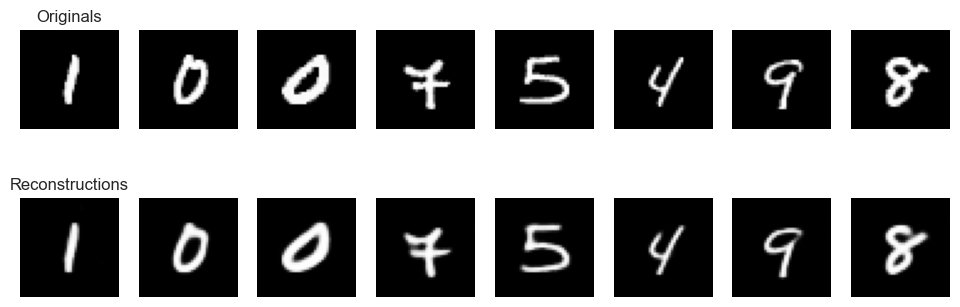

In [47]:
#print recons
if dataset == "bigger_mnist" and is_image_data:
    encoder, decoder = get_conv_vae_mnist40x40_v2(latent_dim=128, vae=True)

    if os.path.exists(os.path.join(model_dir_path, f"{modelname}_vae_encoder_40x40_v3.pth")):
        print(f"[cache] Loading pretrained VAE encoder from: {os.path.join(model_dir_path, f'{modelname}_vae_encoder_40x40_v2.pth')}")
        encoder.load_state_dict(torch.load(os.path.join(model_dir_path, f"{modelname}_vae_encoder_40x40_v3.pth"), map_location=device))
    if os.path.exists(os.path.join(model_dir_path, f"{modelname}_vae_decoder_40x40_v3.pth")):
        print(f"[cache] Loading pretrained VAE decoder from: {os.path.join(model_dir_path, f'{modelname}_vae_decoder_40x40_v2.pth')}")
        decoder.load_state_dict(torch.load(os.path.join(model_dir_path, f"{modelname}_vae_decoder_40x40_v3.pth"), map_location=device))

    encoder = encoder.to(device).eval()
    decoder = decoder.to(device).eval()
    import torchvision
    import matplotlib.pyplot as plt
    dataiter = iter(val_loader)
    images, labels = next(dataiter)
    images = images.to(device)
    with torch.no_grad():
        mu, log_var = encoder(images)
        std = torch.exp(0.5 * log_var)
        z = mu + std * torch.randn_like(std)
        recon_images = decoder(z)

    print("Shape of images:", images.shape)
    print("Shape of reconstructions:", recon_images.shape)
    #plot original and reconstructions
    fig, axes = plt.subplots(2, 8, figsize=(12, 4))
    for i in range(8):
        axes[0, i].imshow(images[i].cpu().squeeze(), cmap='gray')
        axes[0, i].axis('off')
        axes[1, i].imshow(recon_images[i].cpu().squeeze(), cmap='gray')
        axes[1, i].axis('off')
    axes[0, 0].set_title('Originals')
    axes[1, 0].set_title('Reconstructions')
    plt.show()

In [48]:
W = plt_setup_latex()

In [49]:
#plt.title("ICNN Variants on bigger_mnist")
figure_path = os.path.join(current_path,"experiment_files","export","fig","comparision_supervised_icnn",dataset,transform_name)
os.makedirs(figure_path, exist_ok=True)

C:\Users\Lindner\AppData\Local\Temp\ipykernel_25472\167558174.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=vae_types, y=means, palette="tab10")


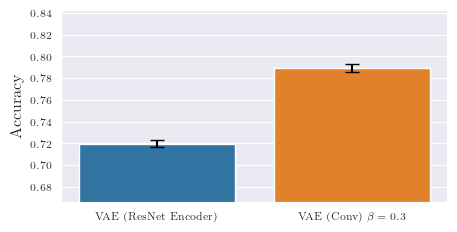

In [50]:
if dataset == "bigger_mnist" and is_image_data:
    import json
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import os

    # Load results
    res_vae_resnet = json.load(open(savepath("learned_vae_confidence_unsupervised_resnet_transformed"), "r"))
    res_vae_best = json.load(open(savepath("learned_vae_confidence_unsupervised_40x40_v6_transformed"), "r"))

    # Prepare data
    vae_types = [
        "VAE (ResNet Encoder)",
        r"VAE (Conv) $\beta=0.3$"
    ]
    means = [
        res_vae_resnet['accuracy_mean'],
        res_vae_best['accuracy_mean']
    ]
    ses = [
        res_vae_resnet.get('accuracy_se', 0),
        res_vae_best.get('accuracy_se', 0)
    ]
    ses = np.array(ses)*1.96

    # Plot
    plt.figure(figsize=(W, W/2))
    ax = sns.barplot(x=vae_types, y=means, palette="tab10")

    # Add SE error bars
    ax.errorbar(x=np.arange(len(vae_types)), y=means, yerr=ses, fmt='none', c='black', capsize=5)

    # Dynamic y-limits
    ymin = min([m - s for m, s in zip(means, ses)]) - 0.05
    ymax = max([m + s for m, s in zip(means, ses)]) + 0.05
    ax.set_ylim(ymin, ymax)

    ax.set_ylabel("Accuracy")
    #plt.title("VAE Confidence Comparison")

    plt.savefig(os.path.join(figure_path,"vae_variants_comparison.pdf"), bbox_inches='tight')
    plt.savefig(os.path.join(figure_path,"vae_variants_comparison.pgf"), bbox_inches='tight', dpi=300)

    plt.show()


C:\Users\Lindner\AppData\Local\Temp\ipykernel_25472\3961599828.py:39: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(x=icnn_types, y=means, palette="tab10", ci=None)
C:\Users\Lindner\AppData\Local\Temp\ipykernel_25472\3961599828.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=icnn_types, y=means, palette="tab10", ci=None)


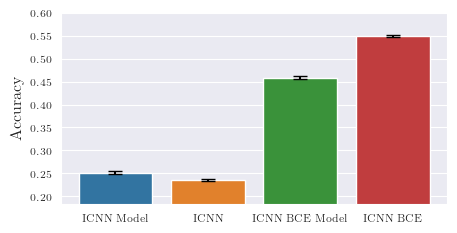

In [51]:
if dataset == "bigger_mnist" and is_image_data:
    import json
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns
    import numpy as np
    import os

    # Load results
    res_icnn = json.load(open(savepath("learned_energy_confidence_icnn_transformed"), "r"))
    res_icnn_no_aug_no_dec = json.load(open(savepath("learned_energy_confidence_icnn_no_aug_no_dec_strat_transformed"), "r"))
    res_icnn_bce = json.load(open(savepath("learned_energy_confidence_icnn_bce_transformed"), "r"))
    res_icnn_bce_no_aug_no_dec = json.load(open(savepath("learned_energy_confidence_icnn_bce_no_aug_no_dec_transformed"), "r"))

    # Prepare data
    icnn_types = [
        "ICNN Model",
        "ICNN",
        "ICNN BCE Model",
        "ICNN BCE"
    ]
    means = [
        res_icnn['accuracy_mean'],
        res_icnn_no_aug_no_dec['accuracy_mean'],
        res_icnn_bce['accuracy_mean'],
        res_icnn_bce_no_aug_no_dec['accuracy_mean']
    ]
    ses = [
        res_icnn.get('accuracy_se', 0),
        res_icnn_no_aug_no_dec.get('accuracy_se', 0),
        res_icnn_bce.get('accuracy_se', 0),
        res_icnn_bce_no_aug_no_dec.get('accuracy_se', 0)
    ]
    ses = np.array(ses)*1.96


    # Plot
    plt.figure(figsize=(W, W/2))
    ax = sns.barplot(x=icnn_types, y=means, palette="tab10", ci=None)

    # Add SE error bars
    ax.errorbar(x=np.arange(len(icnn_types)), y=means, yerr=ses, fmt='none', c='black', capsize=5)

    # Dynamic y-limits
    ymin = min([m - s for m, s in zip(means, ses)]) - 0.05
    ymax = max([m + s for m, s in zip(means, ses)]) + 0.05
    ax.set_ylim(ymin, ymax)

    ax.set_ylabel("Accuracy")

    plt.savefig(os.path.join(figure_path,"icnn_variants_comparison.pdf"), bbox_inches='tight')
    plt.savefig(os.path.join(figure_path,"icnn_variants_comparison.pgf"), bbox_inches='tight', dpi=300)

    plt.show()


In [52]:
#if image data also test a variant with only blur augmentations
if is_image_data:
    energy_model_no_aug_mse = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_no_aug = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =transform_true_function, augment_function=affine_augment,
        decision_strategy=dec_strat,
    )

    energy_conf_no_aug = train_or_load_energy_model(
        copy.deepcopy(energy_model_no_aug_mse), model_dir_path, f"{modelname}_energy2_only_blur_aug_mse_loss", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet10"] else "32",
        }, negative_sampling_module=negative_sampling_module_no_aug, load_if_exists=True,loss_type="mse")
    energy_conf_no_aug.to(device).eval()
    problem_energy_no_aug = TransformationProblem(energy_conf_no_aug, transform_seq,                                              consolidate_method="consolidate_simple")

    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_no_aug,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_only_blur_aug_transformed_mse_loss"), show_progress=True,
        repeats=1)

    #unload values
    del energy_model_no_aug_mse
    del energy_conf_no_aug
    del problem_energy_no_aug
    print(res)

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_energy2_only_blur_aug_mse_loss_energy_conf_best.safetensors
Model has non-negative constraint: False

{'repeats': 5, 'accuracy_mean': 0.968280017375946, 'accuracy_std': 0.0015706642298027873, 'accuracy_se': 0.0007024223975332767, 'f2_macro_mean': 0.9679423570632935, 'f2_macro_std': 0.001593868713825941, 'f2_macro_se': 0.0007127997582649926, 'f2_micro_mean': 0.968280017375946, 'f2_micro_std': 0.0015706642298027873, 'f2_micro_se': 0.0007024223975332767, 'f2_weighted_mean': 0.9682172536849976, 'f2_weighted_std': 0.001573942950926721, 'f2_weighted_se': 0.0007038886861957527, 'per_run': [{'accuracy': 0.9671000242233276, 'f2_macro': 0.9668208360671997, 'f2_micro': 0.9671000242233276, 'f2_weighted': 0.9670429229736328, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': No

In [53]:
#now with discrimator loss
if is_image_data:
    energy_model_no_aug_disc = get_network(dataset_info,architecture, num_classes=1).to(device)


    negative_sampling_module_no_aug = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =transform_true_function, augment_function=affine_augment,
        decision_strategy=dec_strat,
    )

    energy_conf_no_aug_disc = train_or_load_energy_model(
        copy.deepcopy(energy_model_no_aug_disc), model_dir_path, f"{modelname}_energy2_only_blur_aug_disc_loss", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "32",
            "detect_anomaly": False,
        }, negative_sampling_module=negative_sampling_module_no_aug, load_if_exists=True,loss_type="discriminator",optimizer_type=torch.optim.AdamW,gp_weight=5)
    energy_conf_no_aug_disc.to(device).eval()
    problem_energy_no_aug_disc = TransformationProblem(energy_conf_no_aug_disc, transform_seq,                                              consolidate_method="consolidate_simple")

    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_no_aug_disc,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_only_blur_aug_transformed_disc_loss"), show_progress=True,
        repeats=1)

    #unload values
    del energy_model_no_aug_disc
    del energy_conf_no_aug_disc
    del problem_energy_no_aug_disc
    print(res)

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_energy2_only_blur_aug_disc_loss_energy_conf_best.safetensors
Model has non-negative constraint: False

{'repeats': 5, 'accuracy_mean': 0.9698999524116516, 'accuracy_std': 0.0033860146068036556, 'accuracy_se': 0.001514271766724039, 'f2_macro_mean': 0.9696431159973145, 'f2_macro_std': 0.003380949143320322, 'f2_macro_se': 0.0015120064225867837, 'f2_micro_mean': 0.9698999524116516, 'f2_micro_std': 0.0033860146068036556, 'f2_micro_se': 0.001514271766724039, 'f2_weighted_mean': 0.9698644876480103, 'f2_weighted_std': 0.003395398147404194, 'f2_weighted_se': 0.0015184682136545257, 'per_run': [{'accuracy': 0.9639999866485596, 'f2_macro': 0.9637437462806702, 'f2_micro': 0.9639999866485596, 'f2_weighted': 0.9639488458633423, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': N

In [54]:
#now with discrimantitro lsos and no dec strat
if is_image_data:
    energy_model_no_aug_disc_no_dec_strat = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_no_aug_no_dec_strat = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =transform_true_function, augment_function=affine_augment,
        decision_strategy=None,
    )

    energy_conf_no_aug_disc_no_dec_strat = train_or_load_energy_model(
        copy.deepcopy(energy_model_no_aug_disc_no_dec_strat), model_dir_path, f"{modelname}_energy2_only_blur_aug_disc_loss_no_dec_strat", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "32",
        }, negative_sampling_module=negative_sampling_module_no_aug_no_dec_strat, load_if_exists=True,loss_type="discriminator",optimizer_type=torch.optim.AdamW,gp_weight=5)
    energy_conf_no_aug_disc_no_dec_strat.to(device).eval()
    problem_energy_no_aug_disc_no_dec_strat = TransformationProblem(energy_conf_no_aug_disc_no_dec_strat, transform_seq,                                              consolidate_method="consolidate_simple")

    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_no_aug_disc_no_dec_strat,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_only_blur_aug_transformed_disc_loss_no_dec_strat"), show_progress=True,
        repeats=1)
    #unload values
    del energy_model_no_aug_disc_no_dec_strat
    del energy_conf_no_aug_disc_no_dec_strat
    del problem_energy_no_aug_disc_no_dec_strat
    print(res)

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_energy2_only_blur_aug_disc_loss_no_dec_strat_energy_conf_best.safetensors
Model has non-negative constraint: False

{'repeats': 5, 'accuracy_mean': 0.7732399702072144, 'accuracy_std': 0.0025520718190819025, 'accuracy_se': 0.0011413212141857358, 'f2_macro_mean': 0.76887446641922, 'f2_macro_std': 0.0026082564145326614, 'f2_macro_se': 0.0011664477291289802, 'f2_micro_mean': 0.7732399702072144, 'f2_micro_std': 0.0025520718190819025, 'f2_micro_se': 0.0011413212141857358, 'f2_weighted_mean': 0.7716199159622192, 'f2_weighted_std': 0.002557276049628854, 'f2_weighted_se': 0.0011436486168404484, 'per_run': [{'accuracy': 0.7742000222206116, 'f2_macro': 0.7699426412582397, 'f2_micro': 0.7742000222206116, 'f2_weighted': 0.772585391998291, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sampl

In [55]:
#now bce loss with adamw
if is_image_data:
    energy_model_no_aug_bce = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_no_aug_bce = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =transform_true_function, augment_function=affine_augment,
        decision_strategy=dec_strat,
    )

    energy_conf_no_aug_bce = train_or_load_energy_model(
        copy.deepcopy(energy_model_no_aug_bce), model_dir_path, f"{modelname}_energy2_only_blur_aug_bce_loss", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet"] else "32",
        }, negative_sampling_module=negative_sampling_module_no_aug_bce, load_if_exists=True,loss_type="bce",optimizer_type=torch.optim.AdamW)
    energy_conf_no_aug_bce.to(device).eval()
    problem_energy_no_aug_bce = TransformationProblem(energy_conf_no_aug_bce, transform_seq,                                              consolidate_method="consolidate_simple")

    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_no_aug_bce,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_only_blur_aug_transformed_bce_loss"), show_progress=True,
        repeats=1)

    #unload values
    del energy_model_no_aug_bce
    del energy_conf_no_aug_bce
    del problem_energy_no_aug_bce
    print(res)

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_energy2_only_blur_aug_bce_loss_energy_conf_best.safetensors
Model has non-negative constraint: False

{'repeats': 5, 'accuracy_mean': 0.9764599800109863, 'accuracy_std': 0.0013030896661803126, 'accuracy_se': 0.0005827594148713376, 'f2_macro_mean': 0.9762783050537109, 'f2_macro_std': 0.0013442799681797624, 'f2_macro_se': 0.0006011802779282405, 'f2_micro_mean': 0.9764599800109863, 'f2_micro_std': 0.0013030896661803126, 'f2_micro_se': 0.0005827594148713376, 'f2_weighted_mean': 0.9764379262924194, 'f2_weighted_std': 0.0013062894577160478, 'f2_weighted_se': 0.000584190405148884, 'per_run': [{'accuracy': 0.9754999876022339, 'f2_macro': 0.975304365158081, 'f2_micro': 0.9754999876022339, 'f2_weighted': 0.9754729270935059, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': 

In [56]:
#now margin and triplet loss(dont support dec strat)
if is_image_data:
    energy_model_no_aug_margin = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_no_aug_margin = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =transform_true_function, augment_function=affine_augment,
        decision_strategy=None,
    )

    energy_conf_no_aug_margin = train_or_load_energy_model(
        copy.deepcopy(energy_model_no_aug_margin), model_dir_path, f"{modelname}_energy2_only_blur_aug_margin_loss", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet"] else "32",
        }, negative_sampling_module=negative_sampling_module_no_aug_margin, load_if_exists=True,loss_type="margin", monitor="val_auroc")
    energy_conf_no_aug_margin.to(device).eval()
    problem_energy_no_aug_margin = TransformationProblem(energy_conf_no_aug_margin, transform_seq,                                              consolidate_method="consolidate_simple")

    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_no_aug_margin,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_only_blur_aug_transformed_margin_loss"), show_progress=True,
        repeats=1)

    #unload values
    del energy_model_no_aug_margin
    del energy_conf_no_aug_margin
    del problem_energy_no_aug_margin
    print(res)

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_energy2_only_blur_aug_margin_loss_energy_conf_best.safetensors
Model has non-negative constraint: False

{'repeats': 5, 'accuracy_mean': 0.7466999888420105, 'accuracy_std': 0.00330453016795218, 'accuracy_se': 0.001477830817847974, 'f2_macro_mean': 0.7429474592208862, 'f2_macro_std': 0.0034519254695624113, 'f2_macro_se': 0.0015437480006408866, 'f2_micro_mean': 0.7466999888420105, 'f2_micro_std': 0.00330453016795218, 'f2_micro_se': 0.001477830817847974, 'f2_weighted_mean': 0.7455147504806519, 'f2_weighted_std': 0.0033295045141130686, 'f2_weighted_se': 0.0014889996849898458, 'per_run': [{'accuracy': 0.7501999735832214, 'f2_macro': 0.7464962005615234, 'f2_micro': 0.7501999735832214, 'f2_weighted': 0.7489373683929443, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': N

In [57]:
if is_image_data:
    energy_model_no_aug_triplet = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_no_aug_triplet = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =transform_true_function, augment_function=affine_augment,
        decision_strategy=None,
    )

    energy_conf_no_aug_triplet = train_or_load_energy_model(
        copy.deepcopy(energy_model_no_aug_triplet), model_dir_path, f"{modelname}_energy2_only_blur_aug_triplet_loss", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet"] else "32",
        }, negative_sampling_module=negative_sampling_module_no_aug_triplet, load_if_exists=True,loss_type="triplet", monitor="val_smaller")
    energy_conf_no_aug_triplet.to(device).eval()
    problem_energy_no_aug_triplet = TransformationProblem(energy_conf_no_aug_triplet, transform_seq,                                              consolidate_method="consolidate_simple")

    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_no_aug_triplet,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_only_blur_aug_transformed_triplet_loss"), show_progress=True,
        repeats=1)

    #unload values
    del energy_model_no_aug_triplet
    del energy_conf_no_aug_triplet
    del problem_energy_no_aug_triplet
    print(res)

Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_energy2_only_blur_aug_triplet_loss_energy_conf_best.safetensors
Model has non-negative constraint: False

{'repeats': 5, 'accuracy_mean': 0.7940600514411926, 'accuracy_std': 0.004896222148090601, 'accuracy_se': 0.002189657111214125, 'f2_macro_mean': 0.7905621528625488, 'f2_macro_std': 0.005055210553109646, 'f2_macro_se': 0.0022607588874654955, 'f2_micro_mean': 0.7940600514411926, 'f2_micro_std': 0.004896222148090601, 'f2_micro_se': 0.002189657111214125, 'f2_weighted_mean': 0.7929497957229614, 'f2_weighted_std': 0.005018577445298433, 'f2_weighted_se': 0.002244376063606906, 'per_run': [{'accuracy': 0.7925000190734863, 'f2_macro': 0.7890886068344116, 'f2_micro': 0.7925000190734863, 'f2_weighted': 0.7914314270019531, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': N

In [58]:
#i found out margin loss can actually make use of dec strat so do it
if is_image_data:
    energy_model_no_aug_margin_dec_strat = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_no_aug_margin_dec_strat = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =transform_true_function, augment_function=affine_augment,
        decision_strategy=dec_strat,
    )

    energy_conf_no_aug_margin_dec_strat = train_or_load_energy_model(
        copy.deepcopy(energy_model_no_aug_margin_dec_strat), model_dir_path, f"{modelname}_energy2_only_blur_aug_margin_loss_dec_strat", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet"] else "32",
        }, negative_sampling_module=negative_sampling_module_no_aug_margin_dec_strat, load_if_exists=True,loss_type="margin", monitor="val_auroc")
    energy_conf_no_aug_margin_dec_strat.to(device).eval()
    problem_energy_no_aug_margin_dec_strat = TransformationProblem(energy_conf_no_aug_margin_dec_strat, transform_seq,                                              consolidate_method="consolidate_simple")

    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_no_aug_margin_dec_strat,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_only_blur_aug_transformed_margin_loss_dec_strat"), show_progress=True,
        repeats=1)

    del energy_model_no_aug_margin_dec_strat
    del energy_conf_no_aug_margin_dec_strat
    del problem_energy_no_aug_margin_dec_strat
    print(res)


Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_energy2_only_blur_aug_margin_loss_dec_strat_energy_conf_best.safetensors
Model has non-negative constraint: False

{'repeats': 5, 'accuracy_mean': 0.9749399423599243, 'accuracy_std': 0.0006580387125723064, 'accuracy_se': 0.0002942838586276245, 'f2_macro_mean': 0.9747973680496216, 'f2_macro_std': 0.0006666474509984255, 'f2_macro_se': 0.0002981338034918879, 'f2_micro_mean': 0.9749399423599243, 'f2_micro_std': 0.0006580387125723064, 'f2_micro_se': 0.0002942838586276245, 'f2_weighted_mean': 0.9749091267585754, 'f2_weighted_std': 0.0006582810310646892, 'f2_weighted_se': 0.00029439222675185913, 'per_run': [{'accuracy': 0.9739999771118164, 'f2_macro': 0.9738713502883911, 'f2_micro': 0.9739999771118164, 'f2_weighted': 0.9739760160446167, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_s

C:\Users\Lindner\AppData\Local\Temp\ipykernel_25472\560344811.py:33: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  ax = sns.barplot(data=df_mean, ci=None)


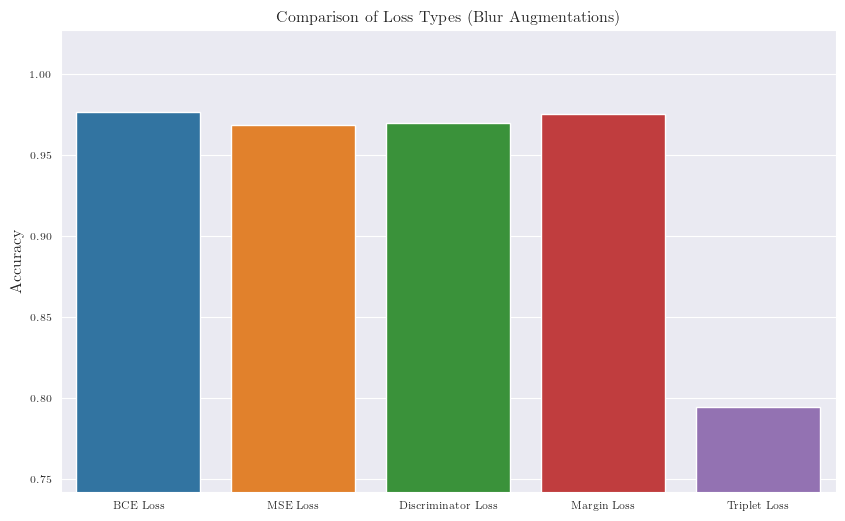

In [59]:
#now do comparision of normal bce loss(blur augmentations) with other looses and plot
if dataset=="bigger_mnist" and is_image_data:
    import json
    import pandas as pd
    import matplotlib.pyplot as plt
    import seaborn as sns

    # Load results for each loss type
    res_bce = json.load(open(savepath("learned_energy_confidence_only_blur_aug_transformed_bce_loss"), "r"))
    res_mse = json.load(open(savepath("learned_energy_confidence_only_blur_aug_transformed_mse_loss"), "r"))
    res_disc = json.load(open(savepath("learned_energy_confidence_only_blur_aug_transformed_disc_loss"), "r"))
    res_margin = json.load(open(savepath("learned_energy_confidence_only_blur_aug_transformed_margin_loss_dec_strat"), "r"))
    res_triplet = json.load(open(savepath("learned_energy_confidence_only_blur_aug_transformed_triplet_loss"), "r"))

    # Prepare DataFrames
    df_mean = pd.DataFrame({
        "BCE Loss": [res_bce['accuracy_mean']],
        "MSE Loss": [res_mse['accuracy_mean']],
        "Discriminator Loss": [res_disc['accuracy_mean']],
        "Margin Loss": [res_margin['accuracy_mean']],
        "Triplet Loss": [res_triplet['accuracy_mean']],
    })
    df_se = pd.DataFrame({
        "BCE Loss": [res_bce['accuracy_se']],
        "MSE Loss": [res_mse['accuracy_se']],
        "Discriminator Loss": [res_disc['accuracy_se']],
        "Margin Loss": [res_margin['accuracy_se']],
        "Triplet Loss": [res_triplet['accuracy_se']],
    }).fillna(0)

    # Plot
    plt.figure(figsize=(10,6))
    ax = sns.barplot(data=df_mean, ci=None)
    ax.set_ylabel("Accuracy")
    ymin = (df_mean - df_se).min().min() - 0.05
    ymax = (df_mean + df_se).max().max() + 0.05
    ax.set_ylim(ymin, ymax)
    plt.title("Comparison of Loss Types (Blur Augmentations)")
    plt.show()

In [60]:
from utils.transforms.apply import grid_resample_bilinear

if dataset=="bigger_mnist" and is_image_data:
    from experiment_thesis.dataset_preperation.get_dataset import get_dataset_info, get_dataset

    dataset_info2 = get_dataset_info(dataset)
    dataset_info2.resample_method = grid_resample_bilinear
    dataset_dict2 = get_dataset(dataset_info2, path=experiment_files_path_data, batch_size=dataset_info2.batch_size)
    transform_name = dataset_info2.transform_seq_name

    dataset_dict2.keys()
    dataset_train_bilinear = dataset_dict2['train_dataset']
    dataset_val_bilinear = dataset_dict2['val_dataset']
    dataset_test_bilinear = dataset_dict2['test_dataset']
    train_loader_bilinear = dataset_dict2['train_loader']
    val_loader_bilinear = dataset_dict2['val_loader']
    test_loader_bilinear = dataset_dict2['test_loader']
    train_loader_transformed_bilinear = dataset_dict2['train_loader_transformed']
    val_loader_transformed_bilinear = dataset_dict2['val_loader_transformed']
    test_loader_transformed_bilinear = dataset_dict2['test_loader_transformed']
    train_loader_no_shuffle_bilinear = dataset_dict2['train_loader_no_shuffle']
    #%%
    energy_model_bilinear = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_bilinear = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =transform_true_function, augment_function=affine_augment,
        decision_strategy=dec_strat,
    )
    energy_conf_bilinear = train_or_load_energy_model(
        energy_model_bilinear, model_dir_path, f"{modelname}_energy2_bilinear", train_loader_bilinear,
        val_loader_bilinear, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet"] else "32",
        }, negative_sampling_module=negative_sampling_module_bilinear, load_if_exists=True)

    energy_conf_bilinear.to(device).eval()
    problem_energy_bilinear = TransformationProblem(energy_conf_bilinear, transform_seq,                                              consolidate_method="consolidate_simple")
    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_bilinear,
        test_loader=test_loader_transformed_bilinear, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_bilinear_transformed"), show_progress=True,
        repeats=1)

    del energy_model_bilinear
    del energy_conf_bilinear
    del problem_energy_bilinear
    print(res)

    energy_model_bilinear_no_aug = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_bilinear_no_aug = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =None, augment_function=None,
        decision_strategy=dec_strat,
    )
    energy_conf_bilinear_no_aug = train_or_load_energy_model(
        energy_model_bilinear_no_aug, model_dir_path, f"{modelname}_energy2_bilinear_no_aug", train_loader_bilinear,
        val_loader_bilinear, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet"] else "32",
        }, negative_sampling_module=negative_sampling_module_bilinear_no_aug, load_if_exists=True)

    energy_conf_bilinear_no_aug.to(device).eval()
    problem_energy_bilinear_no_aug = TransformationProblem(energy_conf_bilinear_no_aug, transform_seq,                                              consolidate_method="consolidate_simple")
    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_bilinear_no_aug,
        test_loader=test_loader_transformed_bilinear, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_bilinear_no_aug_transformed"), show_progress=True,
        repeats=1)

    del energy_model_bilinear_no_aug
    del energy_conf_bilinear_no_aug
    del problem_energy_bilinear_no_aug
    print(res)

    #now bilinear with no dec strat
    energy_model_bilinear_no_aug_no_dec_strat = get_network(dataset_info,architecture, num_classes=1).to(device)
    negative_sampling_module_bilinear_no_aug_no_dec_strat = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =None, augment_function=None,
        decision_strategy=None,
    )
    energy_conf_bilinear_no_aug_no_dec_strat = train_or_load_energy_model(
        energy_model_bilinear_no_aug_no_dec_strat, model_dir_path, f"{modelname}_energy2_bilinear_no_aug_no_dec_strat", train_loader_bilinear,
        val_loader_bilinear, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "16-mixed" if dataset_info.name not in ["modelnet"] else "32",
        }, negative_sampling_module=negative_sampling_module_bilinear_no_aug_no_dec_strat, load_if_exists=True)

    energy_conf_bilinear_no_aug_no_dec_strat.to(device).eval()
    problem_energy_bilinear_no_aug_no_dec_strat = TransformationProblem(energy_conf_bilinear_no_aug_no_dec_strat, transform_seq,                                              consolidate_method="consolidate_simple")
    res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_energy_bilinear_no_aug_no_dec_strat,
        test_loader=test_loader_transformed_bilinear, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath("learned_energy_confidence_bilinear_no_aug_no_dec_strat_transformed"), show_progress=True,
        repeats=1)

    del energy_model_bilinear_no_aug_no_dec_strat
    del energy_conf_bilinear_no_aug_no_dec_strat
    del problem_energy_bilinear_no_aug_no_dec_strat
    print(res)




Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_energy2_bilinear_energy_conf_best.safetensors
Model has non-negative constraint: False

{'repeats': 5, 'accuracy_mean': 0.9756600260734558, 'accuracy_std': 0.00047749653458595276, 'accuracy_se': 0.00021354294207095393, 'f2_macro_mean': 0.9754210710525513, 'f2_macro_std': 0.0004394586430862546, 'f2_macro_se': 0.00019653187984813663, 'f2_micro_mean': 0.9756600260734558, 'f2_micro_std': 0.00047749653458595276, 'f2_micro_se': 0.00021354294207095393, 'f2_weighted_mean': 0.9756369590759277, 'f2_weighted_std': 0.00047469802666455507, 'f2_weighted_se': 0.00021229141128139057, 'per_run': [{'accuracy': 0.9757000207901001, 'f2_macro': 0.9754845499992371, 'f2_micro': 0.9757000207901001, 'f2_weighted': 0.9756802320480347, 'per_sample_errors': None, 'per_sample_matrices': None, 'per_sample_true_labels': None, 'per_sample_pred_labels': None, 'per_sample_correct': None}

In [61]:

import os
import glob
import torch

# Imports from the same notebook / project (these were defined/imported earlier)
from confidence.supervised.ml.vae_with_convex import ICNN
# get_conv_vae_mnist40x40_v2 was defined earlier in this notebook
# if not available, import the proper constructor instead

# --- locate project root and model dir (robust if variables missing) ---
if "current_path" not in globals():
    current_path = os.getcwd()
    while not os.path.exists(os.path.join(current_path, "experiment_files")) and current_path != os.path.dirname(current_path):
        current_path = os.path.dirname(current_path)

model_dir_path = os.path.join(current_path, "experiment_files", "models")
# reuse modelname if present otherwise infer from dataset/architecture used earlier
modelname = globals().get("modelname", None)
if modelname is None:
    # fallback: try to find a single modelname by listing files (best-effort)
    files = os.listdir(model_dir_path) if os.path.exists(model_dir_path) else []
    candidates = [f for f in files if f.endswith(".pth") or f.endswith(".ckpt")]
    modelname = candidates[0].split("_")[0] if candidates else "model"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# --- VAE v5 encoder / decoder load ---
enc_name = f"{modelname}_vae_encoder_40x40_v5.pth"
dec_name = f"{modelname}_vae_decoder_40x40_v5.pth"
enc_path = os.path.join(model_dir_path, enc_name)
dec_path = os.path.join(model_dir_path, dec_name)

vae_loaded = False
if os.path.exists(enc_path) and os.path.exists(dec_path):
        encoder, decoder = get_conv_vae_mnist40x40_v2(latent_dim=128, vae=True)
        encoder.load_state_dict(torch.load(enc_path, map_location=device))
        decoder.load_state_dict(torch.load(dec_path, map_location=device))
        encoder = encoder.to(device).eval()
        decoder = decoder.to(device).eval()
        vae_loaded = True
        print(f"[OK] Loaded VAE v5 encoder from `{enc_path}` and decoder from `{dec_path}`")


vae_conf = VAEConfidence(encoder, decoder, 128,beta=0.2).to(device)
#evaluate vae confidence





icnn = ICNN(n_filters=32, kernel_size=3, n_layers=8)
negative_sampling_module_icnn_bce_no_aug_no_dec = BatchNegativeSampler(
        TransformLatentSamplingStrategy(
            transform_sequence=transform_seq, ), transform_true_function
        =None, augment_function=None,
        decision_strategy=None,
    )

energy_conf_icnn_bce_no_aug_no_dec = train_or_load_energy_model(
        energy_model_icnn_bce_no_aug_no_dec, model_dir_path, f"{modelname}_energy_ICNN_bce_no_aug_no_dec", train_loader,
        val_loader, trainer_kwargs={
            "accelerator": "auto",
            "max_epochs": dataset_info.epochs//2,
            "precision": "32",
        }, negative_sampling_module=negative_sampling_module_icnn_bce_no_aug_no_dec, load_if_exists=True, loss_type = "bce",monitor= "val_acc",monitor_mode="max",optimizer_type=torch.optim.AdamW)


class CombinedConfidence(torch.nn.Module):
    def __init__(self, vae_confidence, energy_confidence,alpha=0.5):
        super(CombinedConfidence, self).__init__()
        self.vae_confidence = vae_confidence
        self.energy_confidence = energy_confidence
        self.alpha = alpha  # Weighting factor between 0 and 1

    def forward(self, x,y=None):
        vae_score = self.vae_confidence(x,y)
        energy_score,_ = self.energy_confidence(x,y)
        combined_score = vae_score + self.alpha * energy_score
        return combined_score,None

problem_combined= TransformationProblem(
        CombinedConfidence(vae_conf, energy_conf_icnn_bce_no_aug_no_dec,alpha=0.2), transform_seq,                                              consolidate_method="consolidate_simple")
res = load_or_run_evaluate_confidence_and_search(
        model, optimizer=optimizer, problem=problem_combined,
        test_loader=test_loader_transformed, max_batch_override=dataset_info.batch_size_search,
        save_path=savepath(f"learned_combined_vae_v5_icnn_bce_no_aug_no_dec_transformed_alpha0_5"), show_progress=True,
        repeats=1)


[OK] Loaded VAE v5 encoder from `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_vae_encoder_40x40_v5.pth` and decoder from `C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_vae_decoder_40x40_v5.pth`
Loading existing weights from C:\Users\Lindner\PycharmProjects\experiments_rotation\experiment_files\models\bigger_mnist_resnet_small_energy_ICNN_bce_no_aug_no_dec_energy_conf_best.safetensors
Model has non-negative constraint: True

